In [111]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
# Master
products = pd.read_csv('data\\products.csv')
customers = pd.read_csv('data\\customers.csv')
promotions = pd.read_csv('data\\promotions.csv')
geography = pd.read_csv('data\\geography.csv')
# transaction
orders = pd.read_csv('data\\orders.csv')
order_items = pd.read_csv('data\\order_items.csv')    
shipment = pd.read_csv('data\\shipments.csv')
returns = pd.read_csv('data\\returns.csv')
# Analytical
sales = pd.read_csv('data\\sales.csv')
# Operational
inventory = pd.read_csv('data\\inventory.csv')
web_traffic = pd.read_csv('data\\web_traffic.csv')


In [113]:
order_items['promo_id'] = order_items['promo_id'].fillna('No_Promo')
order_items['is_promoted'] = np.where(order_items['promo_id'] == 'No_Promo', 0, 1)
order_items_enhanced = pd.merge(
    order_items,
    # Chỉ chọn những cột thực sự mang lại ý nghĩa tính toán để tránh làm phình dữ liệu
    promotions[['promo_id', 'promo_type', 'discount_value', 'min_order_value']], 
    on='promo_id',
    how='left'
)


In [114]:
import pandas as pd
import numpy as np

print("--- XÂY DỰNG LẠI DEMAND_DF VÀ BẢN ĐỒ NHU CẦU KỲ VỌNG ---")

# ==========================================
# 1. ĐỌC DỮ LIỆU VÀ GHÉP TRỤC THỜI GIAN
# ==========================================

# Ghép order_date từ bảng orders sang từng sản phẩm trong order_items
item_with_date = pd.merge(
    order_items,
    orders[['order_id', 'order_date', 'order_status']], 
    on='order_id', 
    how='left'
)

# ==========================================
# 2. TỔNG HỢP DEMAND_DF THEO NGÀY
# ==========================================
# Gom nhóm theo ngày để đếm tổng số sản phẩm và số lượng đơn hàng duy nhất
demand_df = item_with_date.groupby('order_date').agg(
    total_items_sold=('quantity', 'sum'),           # Số sản phẩm bán ra thực tế
    unique_orders=('order_id', 'nunique')           # Số đơn hàng thực tế
).reset_index()

# Đổi tên cột cho đồng nhất và chuyển sang định dạng datetime
demand_df = demand_df.rename(columns={'order_date': 'Date'})
demand_df['Date'] = pd.to_datetime(demand_df['Date'])

# ==========================================
# 3. TẠO BẢN ĐỒ NHU CẦU KỲ VỌNG (CHỐNG LEAKAGE)
# ==========================================
# Lấy ra tháng và thứ trong tuần
demand_df['month'] = demand_df['Date'].dt.month
demand_df['day_of_week'] = demand_df['Date'].dt.dayofweek

# Tính trung vị (median) để tạo giá trị kỳ vọng áp dụng được cho tương lai
expected_demand_map = demand_df.groupby(['month', 'day_of_week']).agg(
    expected_items_sold=('total_items_sold', 'median'), 
    expected_unique_orders=('unique_orders', 'median')
).reset_index()

print("-> Xây dựng demand_df và Bản đồ Nhu cầu thành công!")
print(expected_demand_map.head())

--- XÂY DỰNG LẠI DEMAND_DF VÀ BẢN ĐỒ NHU CẦU KỲ VỌNG ---
-> Xây dựng demand_df và Bản đồ Nhu cầu thành công!
   month  day_of_week  expected_items_sold  expected_unique_orders
0      1            0                548.0                   104.0
1      1            1                489.0                    95.0
2      1            2                404.0                    76.0
3      1            3                386.0                    77.0
4      1            4                391.0                    79.0


In [115]:
promos = promotions.copy()
promos['start_date'] = pd.to_datetime(promos['start_date'])

In [116]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. TẠO KHUNG THỜI GIAN CƠ BẢN (2012 - 2024)
# ==========================================
# Phạm vi dữ liệu theo đề bài: từ 04/07/2012 đến 01/07/2024 [cite: 19, 115]
start_date = '2012-07-04'
end_date = '2024-07-01'
df_calendar = pd.DataFrame({'Date': pd.date_range(start=start_date, end=end_date)})
sales['Date'] = pd.to_datetime(sales['Date'])
df_calendar = df_calendar.merge(sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')

# --- 1.1 Đặc trưng Lịch biểu & Chu kỳ (Lượng giác) ---
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek
df_calendar['day_of_month'] = df_calendar['Date'].dt.day
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['quarter'] = df_calendar['Date'].dt.quarter
df_calendar['is_weekend'] = df_calendar['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
# Chuyển đổi tính chu kỳ (Seasonality) bằng hàm Sin/Cos
day_of_year = df_calendar['Date'].dt.dayofyear
df_calendar['sin_365'] = np.sin(2 * np.pi * day_of_year / 365.25)
df_calendar['cos_365'] = np.cos(2 * np.pi * day_of_year / 365.25)

# ==========================================
# 2. TÍCH HỢP DỮ LIỆU KHUYẾN MÃI (PROMOTIONS)
# ==========================================

promos['start_date'] = pd.to_datetime(promos['start_date'])
promos['end_date'] = pd.to_datetime(promos['end_date'])

# Tính toán các chỉ số khuyến mãi cho từng ngày (Hợp lệ cho cả tương lai)
promo_stats = []
for current_date in df_calendar['Date']:
    active = promos[(promos['start_date'] <= current_date) & (promos['end_date'] >= current_date)]
    if len(active) > 0:
        max_discount = active['discount_value'].max()
        is_stackable = 1 if active['stackable_flag'].sum() > 0 else 0
    else:
        max_discount = 0
        is_stackable = 0
    promo_stats.append({
        'Date': current_date,
        'active_promos_count': len(active),
        'max_discount_depth': max_discount,
        'is_stackable_day': is_stackable
    })

df_calendar = pd.merge(df_calendar, pd.DataFrame(promo_stats), on='Date', how='left')

# ==========================================
# 3. ĐẶC TRƯNG NGÀY LỄ & SỰ KIỆN (EVENTS)
# ==========================================
def assign_event_flags(df):
    month = df['Date'].dt.month
    day = df['Date'].dt.day
    
    # Các ngày lễ chính tại Việt Nam
    holiday_mask = (
        ((day == 30) & (month == 4)) | ((day == 1) & (month == 5)) | 
        ((day == 2) & (month == 9)) | ((day == 1) & (month == 1)) |
        ((day == 14) & (month == 2)) | ((day == 8) & (month == 3))
    )
    df['is_holiday'] = 0
    df.loc[holiday_mask, 'is_holiday'] = 1
    
    # Hiệu ứng mua sắm trước lễ
    df['is_near_holiday'] = df['is_holiday'].shift(-1).fillna(0) + df['is_holiday'].shift(-2).fillna(0)
    df['is_near_holiday'] = df['is_near_holiday'].apply(lambda x: 1 if x > 0 else 0)

    # Ngày Siêu Sale thương mại điện tử
    df['is_super_sale'] = 0
    super_sale_mask = ((day == month) & (month >= 9)) | ((day == 15) & (month >= 9)) | ((day == 25) & (month >= 9))
    df.loc[super_sale_mask, 'is_super_sale'] = 1
    
    # Ngày nhận lương (Payday)
    df['is_payday'] = 0
    payday_mask = (day <= 5) | (day >= 28)
    df.loc[payday_mask, 'is_payday'] = 1
    
    return df

df_calendar = assign_event_flags(df_calendar)

# ==========================================
# 4. TRAFFIC KỲ VỌNG (CHỐNG LEAKAGE)
# ==========================================
# Sử dụng giá trị trung bình lịch sử theo thứ trong tuần và tuần trong năm

web_traffic['date'] = pd.to_datetime(web_traffic['date'])
web_traffic['week_of_year'] = web_traffic['date'].dt.isocalendar().week
web_traffic['day_of_week'] = web_traffic['date'].dt.dayofweek

historical_traffic = web_traffic.groupby(['week_of_year', 'day_of_week']).agg({
    'sessions': 'mean',
    'unique_visitors': 'mean',
    'bounce_rate': 'mean'
}).reset_index().rename(columns={
    'sessions': 'expected_sessions',
    'unique_visitors': 'expected_unique_visitors',
    'bounce_rate': 'expected_bounce_rate'
})

df_calendar['week_of_year'] = df_calendar['Date'].dt.isocalendar().week
df_calendar = pd.merge(df_calendar, historical_traffic, on=['week_of_year', 'day_of_week'], how='left')
df_calendar.drop(columns=['week_of_year'], inplace=True)

# Lấp đầy dữ liệu thiếu (năm 2012) bằng trung vị
#for col in ['expected_sessions', 'expected_unique_visitors', 'expected_bounce_rate']:
#   df_calendar[col] = df_calendar[col].fillna(df_calendar[col].median())

print("Hoàn tất Bước 1: Khởi tạo bảng df_calendar thành công!")
print(df_calendar.head())

Hoàn tất Bước 1: Khởi tạo bảng df_calendar thành công!
        Date     Revenue        COGS  day_of_week  day_of_month  month  \
0 2012-07-04  5123547.94  3982991.19            2             4      7   
1 2012-07-05  2751773.45  2150580.23            3             5      7   
2 2012-07-06  3054029.42  2517632.84            4             6      7   
3 2012-07-07  2667930.94  2108246.62            5             7      7   
4 2012-07-08  2360851.90  1808622.79            6             8      7   

   quarter  is_weekend   sin_365   cos_365  active_promos_count  \
0        3           0 -0.058026 -0.998315                    0   
1        3           0 -0.075190 -0.997169                    0   
2        3           0 -0.092331 -0.995728                    0   
3        3           1 -0.109446 -0.993993                    0   
4        3           1 -0.126528 -0.991963                    0   

   max_discount_depth  is_stackable_day  is_holiday  is_near_holiday  \
0                 0.0    

In [117]:
import pandas as pd
import numpy as np

print("--- ĐANG TRÍCH XUẤT HỒ SƠ HÀNH VI TỪ ORDERS ---")

# 1. Xử lý bảng orders gốc

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['day_of_week'] = orders['order_date'].dt.dayofweek

# Tạo cờ (flag) cho đơn hàng bị hủy
orders['is_cancelled'] = orders['order_status'].apply(lambda x: 1 if x == 'cancelled' else 0)

# 2. Xây dựng Hồ sơ Kỳ vọng theo Tháng và Thứ trong tuần
expected_orders_profile = orders.groupby(['month', 'day_of_week']).agg(
    expected_cancel_rate=('is_cancelled', 'mean') # Tỷ lệ hủy đơn trung bình
).reset_index()

# 3. Tính Giá trị đơn hàng trung bình (AOV) từ tập Sales
# Lấy bảng sales đã có doanh thu thực tế

sales['Date'] = pd.to_datetime(sales['Date'])
sales['month'] = sales['Date'].dt.month
sales['day_of_week'] = sales['Date'].dt.dayofweek

# Tính AOV = Revenue / Unique Orders (Lấy dữ liệu từ demand_df bạn đã làm trước đó)
# Giả sử bạn kết hợp Sales và số lượng đơn để tính AOV Kỳ vọng
aov_df = pd.merge(sales, demand_df[['Date', 'unique_orders']], on='Date', how='left')
aov_df['daily_AOV'] = aov_df['Revenue'] / aov_df['unique_orders'].replace(0, np.nan)

expected_AOV_profile = aov_df.groupby(['month', 'day_of_week']).agg(
    expected_aov=('daily_AOV', 'median') # Dùng median để chống nhiễu
).reset_index()


# 4. Bơm 2 vũ khí này vào không gian đặc trưng df_calendar
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek

df_calendar = pd.merge(df_calendar, expected_orders_profile, on=['month', 'day_of_week'], how='left')
df_calendar = pd.merge(df_calendar, expected_AOV_profile, on=['month', 'day_of_week'], how='left')

# Lấp đầy NaN bằng giá trị trung vị của toàn bộ lịch sử (để an toàn cho tập Test)
df_calendar['expected_cancel_rate'] = df_calendar['expected_cancel_rate'].fillna(df_calendar['expected_cancel_rate'].median())
df_calendar['expected_aov'] = df_calendar['expected_aov'].fillna(df_calendar['expected_aov'].median())

print("-> Tích hợp thành công: Expected Cancel Rate và Expected AOV")

--- ĐANG TRÍCH XUẤT HỒ SƠ HÀNH VI TỪ ORDERS ---
-> Tích hợp thành công: Expected Cancel Rate và Expected AOV


In [118]:
item_with_date = pd.merge(
    order_items_enhanced,
    orders[['order_id', 'order_date', 'order_status']], 
    on='order_id',
    how='left'
)

In [119]:
daily_features = item_with_date.groupby('order_date').agg(
    total_items_sold=('quantity', 'sum'),           # Tổng sản phẩm bán ra
    total_discount=('discount_value', 'sum'),       # Tổng giá trị đã giảm
    promoted_items_count=('is_promoted', 'sum'),    # Số lượng sản phẩm có áp mã
    unique_orders=('order_id', 'nunique')           # Tổng số lượng đơn hàng
).reset_index()

daily_features = daily_features.rename(columns={'order_date': 'Date'})

In [120]:
# Giả sử bạn đã có df_calendar kéo dài từ 2012 đến 2024
df_calendar['Date'] = pd.to_datetime(df_calendar['Date'])
df_calendar['month'] = df_calendar['Date'].dt.month
df_calendar['day_of_week'] = df_calendar['Date'].dt.dayofweek

# Nối bản đồ nhu cầu vào df_calendar
df_calendar = pd.merge(df_calendar, expected_demand_map, on=['month', 'day_of_week'], how='left')

# Lấp đầy các giá trị trống (nếu có) bằng giá trị trung vị tổng thể để mô hình không bị lỗi
median_items = df_calendar['expected_items_sold'].median()
median_orders = df_calendar['expected_unique_orders'].median()

df_calendar['expected_items_sold'] = df_calendar['expected_items_sold'].fillna(median_items)
df_calendar['expected_unique_orders'] = df_calendar['expected_unique_orders'].fillna(median_orders)

In [121]:

promos['start_date'] = pd.to_datetime(promos['start_date'])
promos['end_date'] = pd.to_datetime(promos['end_date'])

# Quét qua từng ngày trong df_calendar để tìm "Sức ép khuyến mãi đã lên lịch"
planned_promo_stats = []
for current_date in df_calendar['Date']:
    # Tìm các khuyến mãi đang active trong ngày này
    active = promos[(promos['start_date'] <= current_date) & (promos['end_date'] >= current_date)]
    if len(active) > 0:
        planned_discount_depth = active['discount_value'].max() # Mức giảm giá sâu nhất
        active_campaigns = len(active) # Số lượng chiến dịch song song
    else:
        planned_discount_depth = 0
        active_campaigns = 0
        
    planned_promo_stats.append({
        'Date': current_date,
        'planned_discount_depth': planned_discount_depth,
        'active_campaigns': active_campaigns
    })

# Merge planned_promo_stats vào df_calendar

In [122]:
import pandas as pd
import numpy as np

print("--- 📦 TRÍCH XUẤT ĐẶC TRƯNG KỲ VỌNG TỪ INVENTORY ---")

# 1. Đọc dữ liệu Tồn kho


# Đảm bảo có cột month (trong file đã có sẵn nhưng cẩn thận vẫn hơn)
if 'month' not in inventory.columns:
    inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
    inventory['month'] = inventory['snapshot_date'].dt.month

# 2. Xây dựng Hồ sơ Tồn kho Kỳ vọng theo Tháng
# Lấy trung bình/trung vị các chỉ số sức khỏe kho hàng qua các năm
expected_inv_profile = inventory.groupby('month').agg(
    expected_fill_rate=('fill_rate', 'mean'),             # Tỷ lệ đáp ứng đơn hàng kỳ vọng
    expected_stockout_rate=('stockout_flag', 'mean'),     # Tỷ lệ cháy hàng kỳ vọng
    expected_overstock_rate=('overstock_flag', 'mean'),   # Tỷ lệ tồn kho dư thừa kỳ vọng
    expected_sell_through=('sell_through_rate', 'median') # Tốc độ bán hàng trung vị
).reset_index()

# 3. Bơm vào không gian đặc trưng df_calendar
# Giả sử df_calendar đã có cột 'month' (từ ngày Date)
if 'month' not in df_calendar.columns:
    df_calendar['month'] = df_calendar['Date'].dt.month

df_calendar = pd.merge(df_calendar, expected_inv_profile, on='month', how='left')

# Lấp đầy NaN (phòng trường hợp có tháng không có dữ liệu) bằng trung vị toàn cục
for col in ['expected_fill_rate', 'expected_stockout_rate', 'expected_overstock_rate', 'expected_sell_through']:
    df_calendar[col] = df_calendar[col].fillna(expected_inv_profile[col].median())

print("-> ✅ Tích hợp thành công 4 đặc trưng Inventory!")
print(expected_inv_profile.head())

--- 📦 TRÍCH XUẤT ĐẶC TRƯNG KỲ VỌNG TỪ INVENTORY ---
-> ✅ Tích hợp thành công 4 đặc trưng Inventory!
   month  expected_fill_rate  expected_stockout_rate  expected_overstock_rate  \
0      1            0.964975                0.662592                 0.839022   
1      2            0.963565                0.667834                 0.806437   
2      3            0.961840                0.668562                 0.755280   
3      4            0.956875                0.686933                 0.670141   
4      5            0.959155                0.681063                 0.709009   

   expected_sell_through  
0                0.07270  
1                0.08740  
2                0.11225  
3                0.15380  
4                0.14290  


In [128]:
# ==========================================
# BƯỚC 2: MERGE DF_CALENDAR VÀO DỮ LIỆU ĐỂ TẠO TẬP TRAIN & TEST
# ==========================================

# 1. XỬ LÝ TẬP TRAIN (final_df)
# Đọc dữ liệu bán hàng lịch sử (chứa target Revenue và COGS)

sales['Date'] = pd.to_datetime(sales['Date'])
final_df = df_calendar
# Merge df_calendar vào sales. 

# Sắp xếp lại theo thời gian (Rất quan trọng cho việc gán trọng số và Cross-Validation)
final_df = final_df.sort_values('Date').reset_index(drop=True)

# Giữ nguyên logic của demo_before: Cắt bỏ dữ liệu năm 2012 vì chứa nhiều nhiễu/bất thường
#final_df = final_df[final_df['Date'] >= '2013-01-01'].reset_index(drop=True)

# Đảm bảo các cột phân loại (nếu có) được định dạng đúng cho LightGBM
for col in final_df.select_dtypes(include=['object']).columns:
    final_df[col] = final_df[col].astype('category')

final_df['time_step'] = np.arange(len(final_df))

# 2. XỬ LÝ TẬP TEST (future_df)
# Đọc file mẫu từ Kaggle để lấy trục thời gian cần dự báo
sample_sub = pd.read_csv('data\\sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

# Merge đặc trưng từ df_calendar cho tương lai (chính là không gian đặc trưng y hệt tập Train)
future_df = pd.merge(sample_sub[['Date']], df_calendar, on='Date', how='left')
future_df['time_step'] = np.arange(len(future_df))

for col in future_df.select_dtypes(include=['object']).columns:
    future_df[col] = future_df[col].astype('category')

print("Hoàn tất Bước 2: Hợp nhất dữ liệu!")
print(f"Kích thước tập Train (final_df): {final_df.shape}")
print(f"Kích thước tập Test (future_df): {future_df.shape}")
print("\nXem thử 5 dòng đầu tập Train:")
print(final_df.head())

Hoàn tất Bước 2: Hợp nhất dữ liệu!
Kích thước tập Train (final_df): (4381, 29)
Kích thước tập Test (future_df): (548, 29)

Xem thử 5 dòng đầu tập Train:
        Date     Revenue        COGS  day_of_week  day_of_month  month  \
0 2012-07-04  5123547.94  3982991.19            2             4      7   
1 2012-07-05  2751773.45  2150580.23            3             5      7   
2 2012-07-06  3054029.42  2517632.84            4             6      7   
3 2012-07-07  2667930.94  2108246.62            5             7      7   
4 2012-07-08  2360851.90  1808622.79            6             8      7   

   quarter  is_weekend   sin_365   cos_365  ...  expected_bounce_rate  \
0        3           0 -0.058026 -0.998315  ...              0.004589   
1        3           0 -0.075190 -0.997169  ...              0.004685   
2        3           0 -0.092331 -0.995728  ...              0.004534   
3        3           1 -0.109446 -0.993993  ...              0.004028   
4        3           1 -0.126528 -0.9

In [137]:
# Loại bỏ dữ liệu trước tháng 6/2013 để tránh nhiễu từ đống số 0
final2_df = final_df
final_df = final_df[final_df['Date'] < '2023-01-01'].reset_index(drop=True)

In [144]:
from sklearn.linear_model import Ridge

train_df = final_df.iloc[:-(548*2)].copy()
val_df = final_df.iloc[-(548*2):-548].copy()

cols_to_drop = ['Date', 'Revenue', 'COGS']
deterministic_features = [col for col in final_df.columns if col not in cols_to_drop]

# ----------------- PHẦN 1: TÌM XU HƯỚNG TỔNG QUÁT -----------------
from sklearn.linear_model import HuberRegressor
# Thay cho Ridge(alpha=10.0)
trend_model = HuberRegressor(epsilon=1.35)
# Fit trên time_step
trend_model.fit(train_df[['time_step']], train_df['Revenue'])

# Tính Trend cho Train và Val
train_df['Trend'] = trend_model.predict(train_df[['time_step']])
val_df['Trend'] = trend_model.predict(val_df[['time_step']])

# Tính phần dư (Residuals) - Lượng dao động cần mô hình Cây giải quyết
train_df['Residuals'] = train_df['Revenue'] - train_df['Trend']

# ----------------- PHẦN 2: TÌM QUY LUẬT DAO ĐỘNG -----------------
# Dùng LightGBM dự đoán phần dư, có thể bọc trong hàm Optuna của anh để tìm tham số tốt nhất
lgb_model = lgb.LGBMRegressor(n_estimators=500, random_state=42)
lgb_model.fit(
    train_df[deterministic_features], 
    train_df['Residuals']
)

# ----------------- PHẦN 3: HỢP NHẤT DỰ BÁO TƯƠNG LAI --------------
# LightGBM dự đoán phần dao động của tập Val
val_df['Predicted_Residuals'] = lgb_model.predict(val_df[deterministic_features])

# Tổng hợp = Trend + Dao động dự báo
val_df['Final_Revenue_Pred'] = val_df['Trend'] + val_df['Predicted_Residuals']

# Đảm bảo doanh thu không bị âm
val_df['Final_Revenue_Pred'] = np.clip(val_df['Final_Revenue_Pred'], a_min=0, a_max=None)

In [145]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Đánh giá trên tập Validation
rmse = np.sqrt(mean_squared_error(val_df['Revenue'], val_df['Final_Revenue_Pred']))
mae = mean_absolute_error(val_df['Revenue'], val_df['Final_Revenue_Pred'])
r2 = r2_score(val_df['Revenue'], val_df['Final_Revenue_Pred'])

print(f"Validation RMSE: {rmse:,.2f}")
print(f"Validation MAE: {mae:,.2f}")
print(f"Validation R2: {r2:.4f}")

Validation RMSE: 908,027.68
Validation MAE: 667,089.43
Validation R2: 0.7308


In [146]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_hybrid_cv(final_df, deterministic_features, n_splits=5, test_size=548):
    print("=== ĐANG CHẠY CROSS-VALIDATION CHO HYBRID MODEL (RIDGE + LIGHTGBM) ===\n")
    
    # Bắt buộc: Đảm bảo dữ liệu sắp xếp theo chiều mũi tên thời gian
    final_df = final_df.sort_values('Date').reset_index(drop=True)
    
    # Trục thời gian t dùng cho mô hình Linear (Ridge)
    final_df['time_step'] = np.arange(len(final_df))
    
    # Cấu hình TimeSeriesSplit với kích thước tập Validation cố định (ví dụ 1.5 năm = ~548 ngày)
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    metrics = {'rmse': [], 'mae': [], 'r2': []}
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(final_df)):
        # 1. Tách tập Train và Validation cho Fold hiện tại
        train_df = final_df.iloc[train_idx].copy()
        val_df = final_df.iloc[val_idx].copy()
        
        # ---------------- PHẦN 1: TÌM XU HƯỚNG TỔNG QUÁT BẰNG RIDGE ----------------
        trend_model = Ridge(alpha=10.0)
        trend_model.fit(train_df[['time_step']], train_df['Revenue'])
        
        # Lấy Trend cho cả Train và Val
        train_df['Trend'] = trend_model.predict(train_df[['time_step']])
        val_df['Trend'] = trend_model.predict(val_df[['time_step']])
        
        # Bóc tách Trend ra khỏi Doanh thu để lấy Phần dư (Residuals)
        train_df['Residuals'] = train_df['Revenue'] - train_df['Trend']
        val_df_actual_residuals = val_df['Revenue'] - val_df['Trend']
        
        # ---------------- PHẦN 2: DỰ ĐOÁN DAO ĐỘNG BẰNG LIGHTGBM ----------------
        lgb_model = lgb.LGBMRegressor(
            n_estimators=1000, 
            learning_rate=0.03,
            random_state=42, 
            n_jobs=-1,
            verbose=-1
        )
        
        # Cho LightGBM học trên mảng Residuals (Đã triệt tiêu Trend)
        lgb_model.fit(
            train_df[deterministic_features], 
            train_df['Residuals'],
            eval_set=[(val_df[deterministic_features], val_df_actual_residuals)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        # ---------------- PHẦN 3: HỢP NHẤT VÀ ĐÁNH GIÁ ----------------
        # Dự đoán phần dư cho tập Val
        val_df['Pred_Residuals'] = lgb_model.predict(val_df[deterministic_features])
        
        # Ghép Trend và Dao động lại với nhau
        val_df['Final_Pred'] = val_df['Trend'] + val_df['Pred_Residuals']
        
        # Lọc nhiễu: Ép doanh thu âm về 0
        val_df['Final_Pred'] = np.clip(val_df['Final_Pred'], a_min=0, a_max=None)
        
        # ---------------- TÍNH TOÁN CHỈ SỐ ----------------
        rmse = np.sqrt(mean_squared_error(val_df['Revenue'], val_df['Final_Pred']))
        mae = mean_absolute_error(val_df['Revenue'], val_df['Final_Pred'])
        r2 = r2_score(val_df['Revenue'], val_df['Final_Pred'])
        
        metrics['rmse'].append(rmse)
        metrics['mae'].append(mae)
        metrics['r2'].append(r2)
        
        print(f"Fold {fold+1} | Train Size: {len(train_df)} | Val Size: {len(val_df)}")
        print(f"   ➤ RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f}\n")
        
    # In ra trung bình tổng thể
    print("="*50)
    print("=== KẾT QUẢ TRUNG BÌNH CỦA HYBRID MODEL ===")
    print(f"Mean RMSE: {np.mean(metrics['rmse']):,.2f}")
    print(f"Mean MAE:  {np.mean(metrics['mae']):,.2f}")
    print(f"Mean R2:   {np.mean(metrics['r2']):.4f}")
    
    return metrics

# ---------------- CÁCH CHẠY THỬ ----------------
# Anh cần định nghĩa trước danh sách các đặc trưng (features) "chắc chắn biết trong tương lai"
features_list = [
    'day_of_week', 'day_of_month', 'day_of_year', 
    'week_of_year', 'month', 'quarter', 
    'is_weekend', 'is_month_start', 'is_month_end'
    # Thêm 'is_holiday', 'promotion_flag' nếu anh đã tạo
]

# Đảm bảo final_df của anh không có chứa dữ liệu NaN và chạy hàm
cv_results = evaluate_hybrid_cv(final_df, deterministic_features, n_splits=5, test_size=548)

=== ĐANG CHẠY CROSS-VALIDATION CHO HYBRID MODEL (RIDGE + LIGHTGBM) ===

Fold 1 | Train Size: 1093 | Val Size: 548
   ➤ RMSE: 1,390,345.15 | MAE: 1,006,632.95 | R2: 0.7549

Fold 2 | Train Size: 1641 | Val Size: 548
   ➤ RMSE: 1,573,709.54 | MAE: 1,194,716.63 | R2: 0.7637

Fold 3 | Train Size: 2189 | Val Size: 548
   ➤ RMSE: 2,421,038.00 | MAE: 2,070,597.39 | R2: -0.5750

Fold 4 | Train Size: 2737 | Val Size: 548
   ➤ RMSE: 838,449.13 | MAE: 608,136.80 | R2: 0.7705

Fold 5 | Train Size: 3285 | Val Size: 548
   ➤ RMSE: 769,265.34 | MAE: 572,255.30 | R2: 0.7546

=== KẾT QUẢ TRUNG BÌNH CỦA HYBRID MODEL ===
Mean RMSE: 1,398,561.43
Mean MAE:  1,090,467.82
Mean R2:   0.4937


In [153]:
def evaluate_hybrid_with_winsorization(final_df, deterministic_features, percentile=99, window_size):
    tscv = TimeSeriesSplit(n_splits=5, test_size=548, max_train_size=window_size)
    metrics = {'rmse': [], 'r2': []}
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(final_df)):
        train_df = final_df.iloc[train_idx].copy()
        val_df = final_df.iloc[val_idx].copy()
        
        # =================================================================
        # BƯỚC 0: CẮT NGỌN (WINSORIZATION) CHỈ TRÊN TẬP TRAIN
        # =================================================================
        # 1. Tính ngưỡng trần dựa trên phân vị (ví dụ: 99%) của tập Train
        upper_limit = np.percentile(train_df['Revenue'], percentile)
        
        # 2. Cắt các giá trị vượt ngưỡng. (Ngưỡng dưới a_min = 0 vì doanh thu không âm)
        train_df['Revenue_Winsorized'] = np.clip(train_df['Revenue'], a_min=0, a_max=upper_limit)
        
        print(f"Fold {fold+1} | Ngưỡng cắt {percentile}%: {upper_limit:,.0f} VNĐ")
        
        # =================================================================
        # PHẦN 1: TÌM XU HƯỚNG BẰNG RIDGE TRÊN DỮ LIỆU ĐÃ CẮT NGỌN
        # =================================================================
        trend_model = Ridge(alpha=10.0)
        # Lưu ý: Cho Ridge học trên cột Revenue_Winsorized thay vì Revenue gốc
        trend_model.fit(train_df[['time_step']], train_df['Revenue_Winsorized'])
        
        train_df['Trend'] = trend_model.predict(train_df[['time_step']])
        val_df['Trend'] = trend_model.predict(val_df[['time_step']])
        
        # Tính phần dư cho Train dựa trên dữ liệu ĐÃ CẮT NGỌN
        train_df['Residuals'] = train_df['Revenue_Winsorized'] - train_df['Trend']
        
        # Tính phần dư thực tế của Val (KHÔNG CẮT NGỌN) để dùng cho eval_set
        val_df_actual_residuals = val_df['Revenue'] - val_df['Trend']
        
        # =================================================================
        # PHẦN 2 & 3: LIGHTGBM VÀ ĐÁNH GIÁ (Như cũ)
        # =================================================================
        lgb_model = lgb.LGBMRegressor(n_estimators=1000, random_state=42, n_jobs=-1, verbose=-1)
        
        lgb_model.fit(
            train_df[deterministic_features], 
            train_df['Residuals'],
            eval_set=[(val_df[deterministic_features], val_df_actual_residuals)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        val_df['Pred_Residuals'] = lgb_model.predict(val_df[deterministic_features])
        val_df['Final_Pred'] = np.clip(val_df['Trend'] + val_df['Pred_Residuals'], a_min=0, a_max=None)
        
        rmse = np.sqrt(mean_squared_error(val_df['Revenue'], val_df['Final_Pred']))
        r2 = r2_score(val_df['Revenue'], val_df['Final_Pred'])
        
        metrics['rmse'].append(rmse)
        metrics['r2'].append(r2)
        print(f"   ➤ RMSE: {rmse:,.2f} | R2: {r2:.4f}\n")
        
    return metrics
windows_to_test = {
    '3_Years': 1095,
    '4_Years': 1460,
    '5.5_Years': 2000
}
for name, window_size in windows_to_test.items():
    print(f"\n=== TESTING WITH WINDOW SIZE: {name} ({window_size} days) ===")
    cv_results = evaluate_hybrid_with_winsorization(final_df, deterministic_features, percentile=99, windowsize=window_size)

SyntaxError: parameter without a default follows parameter with a default (3188749693.py, line 1)

Giai đoạn của Fold 3: Từ 2018-07-02 00:00:00 đến 2019-12-31 00:00:00


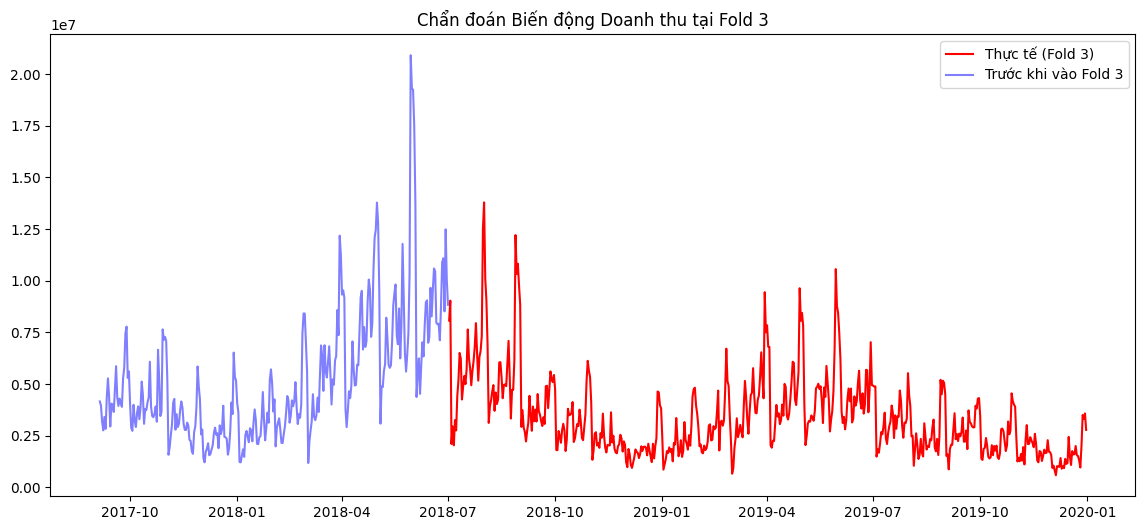

In [147]:
import matplotlib.pyplot as plt

def diagnose_fold_3(final_df, tscv_splits=5, test_size=548):
    # Lấy lại các index chia Fold
    tscv = TimeSeriesSplit(n_splits=tscv_splits, test_size=test_size)
    splits = list(tscv.split(final_df))
    
    # Lấy index của Fold 3 (vị trí số 2 trong list vì Python đếm từ 0)
    train_idx, val_idx = splits[2]
    
    val_df_fold3 = final_df.iloc[val_idx].copy()
    
    print(f"Giai đoạn của Fold 3: Từ {val_df_fold3['Date'].min()} đến {val_df_fold3['Date'].max()}")
    
    plt.figure(figsize=(14, 6))
    plt.plot(val_df_fold3['Date'], val_df_fold3['Revenue'], label='Thực tế (Fold 3)', color='red')
    
    # Vẽ thêm 1 khoảng thời gian của Train trước đó để xem độ gãy
    train_tail = final_df.iloc[train_idx[-300:]] # Lấy 300 ngày cuối của Train
    plt.plot(train_tail['Date'], train_tail['Revenue'], label='Trước khi vào Fold 3', color='blue', alpha=0.5)
    
    plt.title('Chẩn đoán Biến động Doanh thu tại Fold 3')
    plt.legend()
    plt.show()

diagnose_fold_3(final_df)

In [125]:
import pandas as pd
import numpy as np

# 1. BẮT BUỘC: Đảm bảo dữ liệu đã được sắp xếp đúng theo thứ tự thời gian
final_df = final_df.sort_values('Date').reset_index(drop=True)

# 2. Tạo cột Sai phân (Mục tiêu dự đoán mới)
# Công thức: Revenue_diff(t) = Revenue(t) - Revenue(t-1)
final_df['Revenue_diff'] = final_df['Revenue'].diff(1)

# 3. Tạo cột "Mỏ neo" (Lưu lại giá trị của ngày hôm trước để lát cộng ngược lại)
final_df['Revenue_prev'] = final_df['Revenue'].shift(1)

# 4. Loại bỏ dòng NaN đầu tiên do hàm diff() sinh ra
final_df_clean = final_df.dropna(subset=['Revenue_diff', 'Revenue_prev']).copy()

# Tách biến
cols_to_drop = ['Revenue', 'Revenue_diff', 'Date', 'weight_exp', 'weight_linear']

# Giữ lại Revenue_prev trong X để dùng làm mỏ neo giải mã
X = final_df_clean.drop(columns=[c for c in cols_to_drop if c in final_df_clean.columns])
y_diff = final_df_clean['Revenue_diff'] 
y_actual = final_df_clean['Revenue'] # Giữ lại để tính RMSE thực tế

In [126]:
N = len(final_df)
t = np.arange(N)

# ---------------------------------------------------
# CÁCH 1: Trọng số tuyến tính (Linear Weights)
# Scale từ 0.1 (ngày cũ nhất) lên 1.0 (ngày mới nhất)
# ---------------------------------------------------
min_weight = 0.1
max_weight = 1.0
final_df['weight_linear'] = min_weight + (max_weight - min_weight) * (t / (N - 1))

# ---------------------------------------------------
# CÁCH 2: Trọng số hàm mũ (Exponential Weights) - THƯỜNG HIỆU QUẢ HƠN
# w(t) = e^(k * t/N). Ta điều chỉnh k để độ dốc phù hợp.
# ---------------------------------------------------
# Giả sử ta muốn ngày cuối cùng có trọng số là 1.0, 
# và ngày xa nhất trong quá khứ có trọng số cực nhỏ (ví dụ e^-3 ~ 0.05)
k = 1
final_df['weight_exp'] = np.exp(k * (t / (N - 1)) - k)


# In thử để kiểm tra xem trọng số được phân bổ như thế nào
print(final_df[['Date', 'weight_linear', 'weight_exp']].iloc[[0, N//2, -1]])

           Date  weight_linear  weight_exp
0    2012-07-04           0.10    0.367879
1916 2017-10-02           0.55    0.606531
3832 2022-12-31           1.00    1.000000


In [127]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error

def tune_hyperparameters_with_k(X, y, target_name, n_trials=50):
    print(f"--- Đang dùng Optuna săn tìm Tham số + Hệ số k cho {target_name} ---")
    
    # Thiết lập TimeSeriesSplit chuẩn
    tscv = TimeSeriesSplit(n_splits=5, test_size=548)
    
    # Lấy tổng số dòng để phục vụ công thức tính trọng số
    N = len(X)
    t_array = np.arange(N)
    
    def objective(trial):
        # 1. CHO OPTUNA TỰ TÌM k (Phạm vi từ 0.0 đến 9.5 tùy bạn chỉ định)
        k = trial.suggest_float('k_weight', 0.0, 9.5)
        
        # 2. Sinh mảng trọng số hàm mũ ngay tức thì cho giá trị k này
        # Công thức: w(t) = exp(k * (t / (N - 1)) - k)
        current_weights = pd.Series(np.exp(k * (t_array / (N - 1)) - k))
        
        # 3. Các tham số của mô hình LightGBM
        param = {
            'objective': 'regression',
            'metric': 'rmse',
            'random_state': 42,
            'verbose': -1,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 128), 
            'max_depth': trial.suggest_int('max_depth', 4, 10),      
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 30), 
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'alpha': trial.suggest_float('alpha', 1.0, 3.0)
        }

        scores = []
        
        # 4. Chạy Cross-Validation
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
            
            # Cắt lấy đúng mảng trọng số tương ứng cho tập Train của Fold này
            w_tr = current_weights.iloc[train_idx]

            model = lgb.LGBMRegressor(**param)
            
            y_tr_log = np.log1p(y_tr)
            y_va_log = np.log1p(y_va)
            # Đưa w_tr vào tham số sample_weight

            model.fit(
                X_tr, y_tr_log, 
                sample_weight=w_tr,
                eval_set=[(X_va, y_va_log)], 
                callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
            )
            
            preds_log = model.predict(X_va)
            preds_raw = np.expm1(preds_log)
            
            # Tối ưu hóa dựa trên RMSE (có thể đổi sang MAE nếu muốn)
            score = np.sqrt(mean_squared_error(y_va, preds_raw))
            scores.append(score)
            
        # Trả về trung bình RMSE của 5 Folds để Optuna tìm cách giảm thiểu (minimize)
        return np.mean(scores)

    # Đặt hướng tối ưu là 'minimize' vì đang đo bằng RMSE
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"✓ Best RMSE trung bình: {study.best_value:,.2f}")
    print(f"✓ Tham số tối ưu (bao gồm k): {study.best_params}")
    
    return study.best_params

# Cách gọi hàm (chạy trực tiếp trên tập X_train và y_train đã lọc safe_features)
X_train = final_df.drop(columns=['Revenue', 'COGS', 'weight_exp', 'weight_linear', 'Date'])  # Chỉ giữ lại các đặc trưng an toàn
cols_to_check = ['rev_rolling_30_lag_2_years', 'rev_lag_2_years','cogs_rolling_30_lag_2_years', 'cogs_lag_2_years']
mask = X_train[cols_to_check].notnull().all(axis=1)
train_val_clean = X_train[mask].copy()
y_train_revenue = final_df.loc[mask, 'Revenue'].copy()
best_params_revenue = tune_hyperparameters_with_k(train_val_clean, y_train_revenue, "Revenue", n_trials=50)


KeyError: "None of [Index(['rev_rolling_30_lag_2_years', 'rev_lag_2_years',\n       'cogs_rolling_30_lag_2_years', 'cogs_lag_2_years'],\n      dtype='str')] are in the [columns]"

In [ ]:
y_train_cogs = final_df['COGS']
best_params_cogs = tune_hyperparameters_with_k(train_val_clean, y_train_cogs, "COGS", n_trials=50)

[I 2026-04-22 18:26:34,179] A new study created in memory with name: no-name-a3bacb88-3f60-4f24-8324-1cf480ffd41c


--- Đang dùng Optuna săn tìm Tham số + Hệ số k cho COGS ---


[I 2026-04-22 18:26:35,820] Trial 0 finished with value: 1365166.2131391608 and parameters: {'k_weight': 0.7494064309527875, 'learning_rate': 0.019206705994077585, 'num_leaves': 50, 'max_depth': 10, 'min_child_samples': 5, 'subsample': 0.640783253268758, 'colsample_bytree': 0.8707957631853631, 'alpha': 1.6363437642823861}. Best is trial 0 with value: 1365166.2131391608.
[I 2026-04-22 18:26:37,734] Trial 1 finished with value: 1284940.7946201344 and parameters: {'k_weight': 6.232911742293955, 'learning_rate': 0.01243339297239028, 'num_leaves': 80, 'max_depth': 10, 'min_child_samples': 15, 'subsample': 0.6885529071551909, 'colsample_bytree': 0.9838869011998239, 'alpha': 1.6061998333922891}. Best is trial 1 with value: 1284940.7946201344.
[I 2026-04-22 18:26:39,402] Trial 2 finished with value: 1282189.8599412867 and parameters: {'k_weight': 5.441780534269795, 'learning_rate': 0.014552286889663715, 'num_leaves': 80, 'max_depth': 9, 'min_child_samples': 18, 'subsample': 0.9732330190677941,

✓ Best RMSE trung bình: 1,240,889.76
✓ Tham số tối ưu (bao gồm k): {'k_weight': 7.982755024150173, 'learning_rate': 0.059109352103119656, 'num_leaves': 15, 'max_depth': 9, 'min_child_samples': 13, 'subsample': 0.9994956215714477, 'colsample_bytree': 0.7019948716503928, 'alpha': 2.3624936768179072}


In [ ]:
import json
from datetime import datetime

# Lấy thời gian hiện tại để ghi chú vào file
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# ==========================================
# CÁCH 1: LƯU DƯỚI DẠNG FILE TEXT (.txt) ĐỂ ĐỌC
# ==========================================
with open('output\\best_params_optuna.txt', 'w', encoding='utf-8') as f:
    f.write("=== BỘ SIÊU THAM SỐ TỐI ƯU TỪ OPTUNA ===\n")
    f.write(f"Thời gian lưu: {current_time}\n\n")
    
    f.write("--- 1. MÔ HÌNH REVENUE ---\n")
    for key, value in best_params_revenue.items():
        f.write(f"{key}: {value}\n")
        
    f.write("\n--- 2. MÔ HÌNH COGS ---\n")
    for key, value in best_params_cogs.items():
        f.write(f"{key}: {value}\n")

print("✓ Đã xuất cấu hình ra file 'best_params_optuna.txt' (Dễ đọc)")

# ==========================================
# CÁCH 2: LƯU DƯỚI DẠNG TỪ ĐIỂN JSON (.json) ĐỂ DÙNG LẠI CHO CODE
# ==========================================
# Gom 2 bộ tham số vào 1 từ điển lớn
saved_params = {
    "Revenue": best_params_revenue,
    "COGS": best_params_cogs
}

with open('output\\best_params_optuna.json', 'w', encoding='utf-8') as f:
    # indent=4 giúp file json được format thụt lề đẹp mắt
    json.dump(saved_params, f, indent=4)

print("✓ Đã xuất cấu hình ra file 'best_params_optuna.json' (Dễ load lại vào Python)")

✓ Đã xuất cấu hình ra file 'best_params_optuna.txt' (Dễ đọc)
✓ Đã xuất cấu hình ra file 'best_params_optuna.json' (Dễ load lại vào Python)


In [ ]:
import json

# Nạp lại bộ tham số
with open('output\\best_params_optuna.json', 'r', encoding='utf-8') as f:
    loaded_params = json.load(f)

# Lấy ra từng bộ
best_params_rev = loaded_params["Revenue"]
best_params_cogs = loaded_params["COGS"]

print("Đã nạp thành công bộ tham số tối ưu!")

Đã nạp thành công bộ tham số tối ưu!


In [ ]:
N = len(final_df)
t = np.arange(N)
k = best_params_rev['k_weight'] # Lấy k đã tối ưu cho Revenue

final_df['final_weight'] = np.exp(k * (t / (N - 1)) - k)

# --- ĐOẠN ĐÃ SỬA LỖI: Thêm tất cả các biến trọng số vào danh sách cần xóa ---
del_cols = ['Date', 'Revenue', 'COGS', 'weight_linear', 'weight_exp', 'best_weight', 'final_weight']  # Các cột không phải đặc trưng (bao gồm cả các cột trọng số cũ)
safe_features = [col for col in final_df.columns if col not in del_cols]

# Chỉ lấy đúng các đặc trưng hợp lệ (không chứa trọng số hay target)

X_train = final_df[safe_features]
y_train_revenue = final_df['Revenue']
y_train_cogs = final_df['COGS']
w_train = final_df['final_weight']

In [ ]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm
from lightgbm import LGBMRegressor
# ---------------------------------------------------------
# Giả sử final_df đã chứa đầy đủ features, Revenue và sample_weights
# Đảm bảo dữ liệu ĐÃ ĐƯỢC SẮP XẾP theo thời gian
# final_df = final_df.sort_values('Date').reset_index(drop=True)
# ---------------------------------------------------------
with open('output\\best_params_optuna.json', 'r', encoding='utf-8') as f:
    loaded_params = json.load(f)

# Lấy ra từng bộ
best_params_rev = loaded_params["Revenue"]
best_params_cogs = loaded_params["COGS"]

print("Đã nạp thành công bộ tham số tối ưu!")

for col in final_df.select_dtypes(include=['object']).columns:
    final_df[col] = final_df[col].astype('category')

    
# Định nghĩa các biến

target = 'Revenue'
best_k_rev = best_params_rev.pop('k_weight')
final_df['weight_exp'] = np.exp(best_k_rev * (t / (N - 1)) - best_k_rev)
param_rev = best_params_rev

#best_k_cogs = best_params_cogs.pop('k_weight')
#final_df['weight_exp_cogs'] = np.exp(best_k_cogs * (t / (N - 1)) - best_k_cogs)

drop_cols = ['Date', 'Revenue', 'COGS']
features = [c for c in final_df.columns if c not in drop_cols]

X = final_df[features]
y = final_df[target]

weights = final_df['weight_exp'] # Dùng trọng số hàm mũ đã tạo ở bước trước

# Khởi tạo TimeSeriesSplit với 5 nếp gấp (5 splits)
# Bỏ qua nếp gấp đầu tiên nếu nó quá nhỏ bằng tham số max_train_size hoặc test_size (nếu cần)
tscv = TimeSeriesSplit(n_splits=5)

# Các list để lưu trữ điểm số của từng fold
mae_scores = []
rmse_scores = []
r2_scores = []

print("Bắt đầu Cross-Validation...\n")

# Vòng lặp qua từng cửa sổ thời gian
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    
    # Chia tập Train và Validation theo index
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    w_train = weights.iloc[train_index]
    
    # Khởi tạo mô hình
    model = LGBMRegressor(
        learning_rate=param_rev['learning_rate'],
        num_leaves=param_rev['num_leaves'],
        max_depth=param_rev['max_depth'],
        min_child_samples=param_rev['min_child_samples'],
        subsample=param_rev['subsample'],
        colsample_bytree=param_rev['colsample_bytree'],
        n_estimators=500,  
        random_state=42,
        verbose=-1
    )
    
    # Huấn luyện mô hình (truyền trọng số vào tập Train)
    model.fit(
        X_train, 
        y_train, 
        sample_weight=w_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)] # Chống Overfitting
    )
    
    # Dự đoán trên tập Validation
    y_pred = model.predict(X_val)
    
    # Tính toán các chỉ số đánh giá [cite: 228]
    mae = mean_absolute_error(y_val, y_pred) # Tính MAE [cite: 229, 230]
    rmse = np.sqrt(mean_squared_error(y_val, y_pred)) # Tính RMSE [cite: 231, 232]
    r2 = r2_score(y_val, y_pred) # Tính R-squared [cite: 233, 234]
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"Fold {fold+1}:")
    print(f"  Train Size: {len(X_train)} | Val Size: {len(X_val)}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R2:   {r2:.4f}\n")

# Tổng hợp kết quả
print("-" * 30)
print("KẾT QUẢ CROSS-VALIDATION TRUNG BÌNH:")
print(f"Mean MAE:  {np.mean(mae_scores):,.2f}")
print(f"Mean RMSE: {np.mean(rmse_scores):,.2f}")
print(f"Mean R2:   {np.mean(r2_scores):.4f}")

Đã nạp thành công bộ tham số tối ưu!
Bắt đầu Cross-Validation...

Fold 1:
  Train Size: 546 | Val Size: 542
  MAE:  1,112,438.31
  RMSE: 1,588,825.03
  R2:   0.6874

Fold 2:
  Train Size: 1088 | Val Size: 542
  MAE:  1,131,136.00
  RMSE: 1,589,667.71
  R2:   0.7551

Fold 3:
  Train Size: 1630 | Val Size: 542
  MAE:  1,882,618.27
  RMSE: 2,221,092.16
  R2:   -0.3527

Fold 4:
  Train Size: 2172 | Val Size: 542
  MAE:  756,892.45
  RMSE: 1,056,749.51
  R2:   0.6310

Fold 5:
  Train Size: 2714 | Val Size: 542
  MAE:  565,078.28
  RMSE: 761,549.70
  R2:   0.7602

------------------------------
KẾT QUẢ CROSS-VALIDATION TRUNG BÌNH:
Mean MAE:  1,089,632.66
Mean RMSE: 1,443,576.82
Mean R2:   0.4962


In [ ]:
import pandas as pd
import numpy as np

print("--- KHỞI TẠO MA TRẬN ĐẶC TRƯNG TƯƠNG LAI (FUTURE_DF) ---")

# ==========================================
# BƯỚC 1: LẤY TRỤC THỜI GIAN TỪ FILE MẪU KAGGLE
# ==========================================
# Tập sample_submission chứa chính xác 548 ngày cần dự báo (01/01/2023 - 01/07/2024)
sample_sub = pd.read_csv('data\\sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

# ==========================================
# BƯỚC 2: RÁP TỪ ĐIỂN ĐẶC TRƯNG VÀO TƯƠNG LAI
# ==========================================
# Chỉ cần Left Join với df_calendar là future_df sẽ có đủ mọi features hợp lệ
future_df = pd.merge(sample_sub[['Date']], final_df, on='Date', how='left')

# Đảm bảo các cột dạng chuỗi (string/object) được chuyển thành Category cho LightGBM
for col in future_df.select_dtypes(include=['object']).columns:
    future_df[col] = future_df[col].astype('category')

# ==========================================
# BƯỚC 3: TÁCH CỘT DATE VÀ DỌN DẸP TÍNH NĂNG
# ==========================================
# 1. Lấy cột Date cất đi để lát nữa ráp vào file submission.csv
if 'Date' in future_df.columns:
    test_dates = future_df.pop('Date')

# 2. Dọn dẹp X_train_final: Trục xuất toàn bộ các cột không phải là Feature
cols_to_remove = ['best_weight', 'final_weight', 'weight_exp', 'weight_linear', 'Revenue', 'COGS', 'Date']
X_train_final = X_train.copy()  # Giả sử X_train đã được lọc safe_features ở bước trước
for col in cols_to_remove:
    if col in X_train_final.columns:
        X_train_final.drop(columns=[col], inplace=True)

# 3. Lấy danh sách tính năng SẠCH (chỉ chứa các biến hợp lệ)
train_features = X_train_final.columns.tolist()

# 4. Lọc future_df để giữ lại ĐÚNG số lượng và ĐÚNG thứ tự các cột như X_train_final
X_test_final = future_df[train_features]

# ==========================================
# BƯỚC 4: KIỂM TRA LỖI RỖNG (SANITY CHECK)
# ==========================================
missing_cols = X_test_final.columns[X_test_final.isnull().any()].tolist()
if missing_cols:
    print(f"Cảnh báo: Cần lấp đầy NaN cho các cột tương lai: {missing_cols}")
    for col in missing_cols:
        X_test_final[col] = X_test_final[col].fillna(X_test_final[col].median())

print("-> Khớp ma trận thành công!")
print(f"Train features ({len(train_features)}): {train_features}")

# ==========================================
# BƯỚC 4: KIỂM TRA LỖI RỖNG (SANITY CHECK)
# ==========================================
# Kiểm tra xem có đặc trưng nào ở tương lai bị NaN không (do lỗi shift/rolling)
missing_cols = X_test_final.columns[X_test_final.isnull().any()].tolist()
if missing_cols:
    print(f"Cảnh báo: Cần lấp đầy NaN cho các cột tương lai: {missing_cols}")
    # Tự động lấp đầy bằng trung vị của chính nó hoặc 0 tùy bản chất
    for col in missing_cols:
        X_test_final[col] = X_test_final[col].fillna(X_test_final[col].median())

print("-> Tạo ma trận tương lai thành công!")
print(f"-> Kích thước X_test_final: {X_test_final.shape} (Phải khớp số cột với X_train_final là {X_train_final.shape[1]})")

--- KHỞI TẠO MA TRẬN ĐẶC TRƯNG TƯƠNG LAI (FUTURE_DF) ---
Cảnh báo: Cần lấp đầy NaN cho các cột tương lai: ['day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'sin_365', 'cos_365', 'active_promos_count', 'max_discount_depth', 'is_stackable_day', 'is_holiday', 'is_near_holiday', 'is_super_sale', 'is_payday', 'expected_sessions', 'expected_unique_visitors', 'expected_bounce_rate', 'rev_lag_2_years', 'rev_rolling_30_lag_2_years', 'cogs_lag_2_years', 'cogs_rolling_30_lag_2_years', 'expected_cancel_rate', 'expected_aov', 'expected_items_sold', 'expected_unique_orders', 'expected_fill_rate', 'expected_stockout_rate', 'expected_overstock_rate', 'expected_sell_through']
-> Khớp ma trận thành công!
Train features (29): ['day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'sin_365', 'cos_365', 'active_promos_count', 'max_discount_depth', 'is_stackable_day', 'is_holiday', 'is_near_holiday', 'is_super_sale', 'is_payday', 'expected_sessions', 'expected_unique_visitors', 'e

In [ ]:
N = len(final_df)
t = np.arange(N)
k = best_k_rev # Lấy k đã tối ưu cho Revenue

final_df['final_weight'] = np.exp(k * (t / (N - 1)) - k)

print("2. Đang đồng bộ hóa không gian đặc trưng...")

# --- ĐOẠN ĐÃ SỬA LỖI: Thêm tất cả các biến trọng số vào danh sách cần xóa ---
del_cols = ['Date', 'Revenue', 'COGS', 'weight_linear', 'weight_exp', 'best_weight', 'final_weight']
safe_features = [col for col in final_df.columns if col not in del_cols]

# Chỉ lấy đúng các đặc trưng hợp lệ (không chứa trọng số hay target)
X_train = final_df[safe_features]
y_train_revenue = final_df['Revenue']
y_train_cogs = final_df['COGS']
w_train = final_df['final_weight']

# Đọc file mẫu từ Kaggle để lấy trục thời gian test
sample_sub = pd.read_csv('data\\sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

# Lúc này future_df sẽ lấy đúng các cột, không bị dính lỗi KeyError nữa
X_test = future_df[safe_features]

# ---------------------------------------------------------
# BƯỚC 3: HUẤN LUYỆN TOÀN CỤC (FULL-FIT)
# ---------------------------------------------------------
print("3. Đang huấn luyện mô hình với toàn bộ dữ liệu lịch sử...")

# Cấu hình siêu tham số chống Overfitting đã thiết lập từ trước
model_params = {
    'learning_rate': best_params_rev['learning_rate'],
    'num_leaves': best_params_rev['num_leaves'],
    'max_depth': best_params_rev['max_depth'],
    'min_child_samples': best_params_rev['min_child_samples'],
    'subsample': best_params_rev['subsample'],
    'colsample_bytree': best_params_rev['colsample_bytree'],
    'n_estimators': 1000,  
    'random_state': 42,
    'verbose': -1  
}

y_train_revenue_log = np.log1p(final_df['Revenue'])
y_train_cogs_log = np.log1p(final_df['COGS'])

# Khởi tạo và huấn luyện mô hình dự báo Doanh thu (Revenue)
model_revenue = lgb.LGBMRegressor(**model_params)
model_revenue.fit(X_train, y_train_revenue_log, sample_weight=w_train)

# Khởi tạo và huấn luyện mô hình dự báo Giá vốn (COGS)
model_cogs = lgb.LGBMRegressor(**model_params)
model_cogs.fit(X_train, y_train_cogs_log, sample_weight=w_train)


# ---------------------------------------------------------
# BƯỚC 4: DỰ BÁO VÀ ĐÓNG GÓI FILE SUBMISSION
# ---------------------------------------------------------
print("4. Đang tiến hành dự báo và xuất file...")

preds_revenue_log = model_revenue.predict(X_test)
preds_cogs_log = model_cogs.predict(X_test)

multiplier = 1.35

# Bơm trực tiếp kết quả dự báo vào file mẫu sample_sub
# (Vì sample_sub đã có sẵn cột Date và đúng thứ tự dòng mà Kaggle yêu cầu)
sample_sub['Revenue'] = np.maximum(0, np.expm1(preds_revenue_log))
sample_sub['COGS'] = np.maximum(0, np.expm1(preds_cogs_log))
sample_sub['Revenue'] *= multiplier 
sample_sub['COGS'] *= multiplier

# Màng lọc an toàn: Đảm bảo doanh thu và giá vốn không bao giờ bị âm
sample_sub['Revenue'] = np.maximum(0, sample_sub['Revenue'])
sample_sub['COGS'] = np.maximum(0, sample_sub['COGS'])

# Chỉ lấy đúng 3 cột cần thiết đề phòng có cột rác
final_submission = sample_sub[['Date', 'Revenue', 'COGS']]

# Xuất file CSV (bắt buộc index=False để không làm dư cột khi nộp Kaggle)
final_submission.to_csv('output\\submissionlgbm.csv', index=False)

print("✅ Đã xuất file submissionlgbm.csv thành công! Dữ liệu đã sẵn sàng để nộp lên hệ thống.")

2. Đang đồng bộ hóa không gian đặc trưng...
3. Đang huấn luyện mô hình với toàn bộ dữ liệu lịch sử...
4. Đang tiến hành dự báo và xuất file...
✅ Đã xuất file submissionlgbm.csv thành công! Dữ liệu đã sẵn sàng để nộp lên hệ thống.


--- Descriptive Stats: Revenue ---
        Revenue_New  Revenue_Best
count  5.480000e+02  5.480000e+02
mean   2.473737e+06  4.616867e+06
std    4.660867e-10  2.333540e+06
min    2.473737e+06  1.373891e+06
25%    2.473737e+06  2.831448e+06
50%    2.473737e+06  4.098495e+06
75%    2.473737e+06  5.721849e+06
max    2.473737e+06  1.482447e+07

--- Descriptive Stats: COGS ---
           COGS_New     COGS_Best
count  5.480000e+02  5.480000e+02
mean   2.042687e+06  3.929090e+06
std    6.991301e-10  1.996735e+06
min    2.042687e+06  1.074318e+06
25%    2.042687e+06  2.437954e+06
50%    2.042687e+06  3.558643e+06
75%    2.042687e+06  4.706785e+06
max    2.042687e+06  1.213713e+07

Revenue Correlation: 0.0000
Revenue MAE: 2,267,981.50
Revenue RMSE: 3,166,777.77
COGS Correlation: -0.0000

--- Top 10 Days with Highest Revenue Difference ---
          Date   Revenue_New  Revenue_Best      Diff_Rev
150 2023-05-31  2.473737e+06  1.482447e+07 -1.235074e+07
515 2024-05-30  2.473737e+06  1.420991e+07 -1

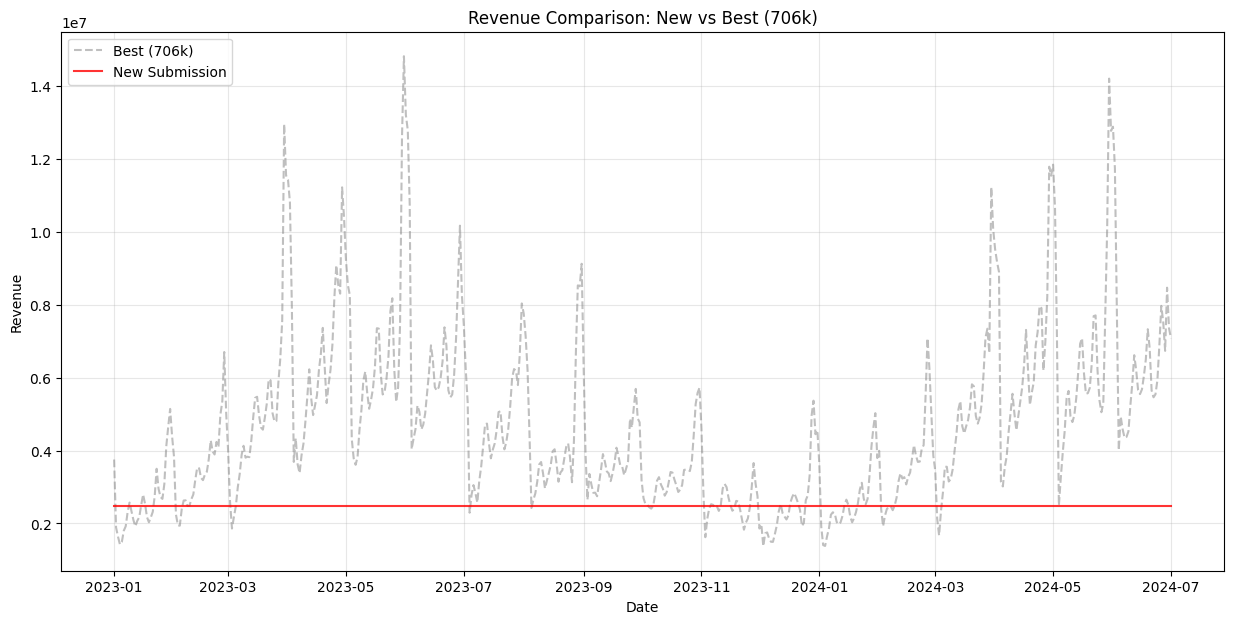

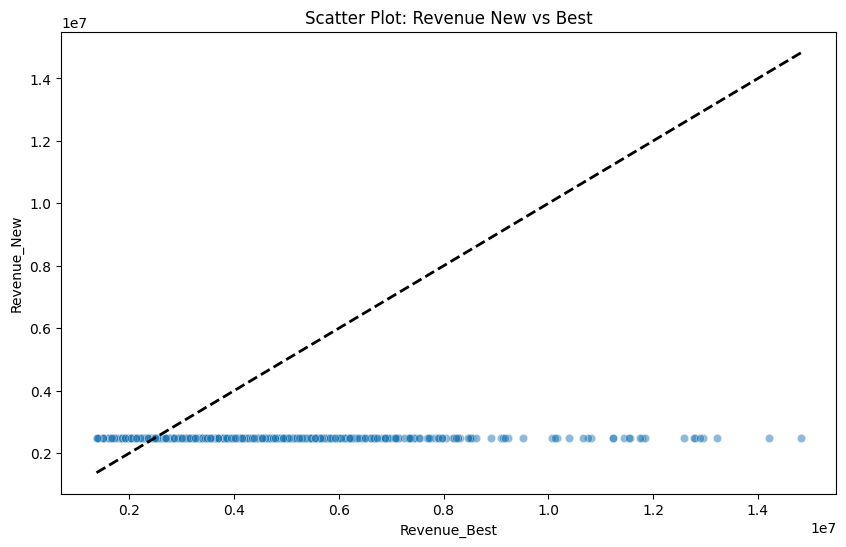

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the files
sub_new = pd.read_csv('output\\submissionlgbm.csv')
sub_best = pd.read_csv('submission_best_706k.csv')

# Ensure Date is datetime
sub_new['Date'] = pd.to_datetime(sub_new['Date'])
sub_best['Date'] = pd.to_datetime(sub_best['Date'])

# Merge to compare
df_comp = pd.merge(sub_new, sub_best, on='Date', suffixes=('_New', '_Best'))

# Basic Stats
stats_rev = df_comp[['Revenue_New', 'Revenue_Best']].describe()
stats_cogs = df_comp[['COGS_New', 'COGS_Best']].describe()

# Metrics
corr_rev = df_comp['Revenue_New'].corr(df_comp['Revenue_Best'])
mae_rev = np.mean(np.abs(df_comp['Revenue_New'] - df_comp['Revenue_Best']))
rmse_rev = np.sqrt(np.mean((df_comp['Revenue_New'] - df_comp['Revenue_Best'])**2))

corr_cogs = df_comp['COGS_New'].corr(df_comp['COGS_Best'])
mae_cogs = np.mean(np.abs(df_comp['COGS_New'] - df_comp['COGS_Best']))

# Differences
df_comp['Diff_Rev'] = df_comp['Revenue_New'] - df_comp['Revenue_Best']
df_comp['Abs_Diff_Rev'] = df_comp['Diff_Rev'].abs()
top_diffs = df_comp.sort_values('Abs_Diff_Rev', ascending=False).head(10)

# Print results
print("--- Descriptive Stats: Revenue ---")
print(stats_rev)
print("\n--- Descriptive Stats: COGS ---")
print(stats_cogs)
print(f"\nRevenue Correlation: {corr_rev:.4f}")
print(f"Revenue MAE: {mae_rev:,.2f}")
print(f"Revenue RMSE: {rmse_rev:,.2f}")
print(f"COGS Correlation: {corr_cogs:.4f}")

print("\n--- Top 10 Days with Highest Revenue Difference ---")
print(top_diffs[['Date', 'Revenue_New', 'Revenue_Best', 'Diff_Rev']])

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(df_comp['Date'], df_comp['Revenue_Best'], label='Best (706k)', color='gray', alpha=0.5, linestyle='--')
plt.plot(df_comp['Date'], df_comp['Revenue_New'], label='New Submission', color='red', alpha=0.8)
plt.title('Revenue Comparison: New vs Best (706k)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('revenue_comparison.png')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_comp, x='Revenue_Best', y='Revenue_New', alpha=0.5)
plt.plot([df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         [df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         'k--', lw=2)
plt.title('Scatter Plot: Revenue New vs Best')
plt.savefig('revenue_scatter.png')

--- PHÂN TÍCH ĐỘ ĐÓNG GÓP CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE) ---

[TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT - REVENUE]
                        Feature  Importance
0    rev_rolling_30_lag_2_years        1551
1                  day_of_month        1445
2               rev_lag_2_years        1429
3                       sin_365        1367
4   cogs_rolling_30_lag_2_years        1359
5                       cos_365        1261
6              cogs_lag_2_years        1207
7          expected_bounce_rate         829
8             expected_sessions         734
9      expected_unique_visitors         664
10          expected_items_sold         568
11                 expected_aov         490
12         expected_cancel_rate         432
13                  day_of_week         391
14       expected_unique_orders         368
15           max_discount_depth         234
16           expected_fill_rate          75
17             is_stackable_day          69
18          active_promos_count          67
19       

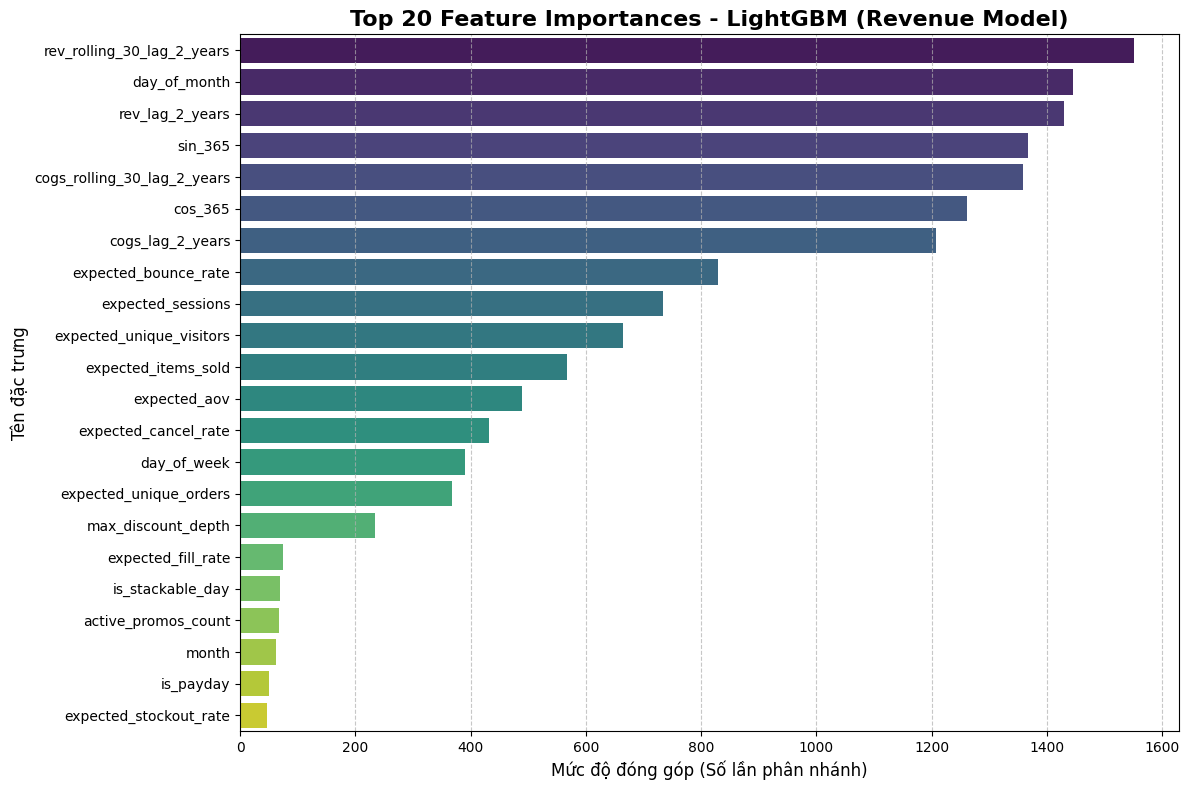

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- PHÂN TÍCH ĐỘ ĐÓNG GÓP CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE) ---")

# 1. Lấy điểm số đóng góp từ mô hình Revenue đã huấn luyện
# Mặc định LightGBM tính theo 'split' (số lần đặc trưng được dùng để chia nhánh)
importances = model_revenue.feature_importances_
features = X_train.columns

# 2. Tạo DataFrame để dễ dàng sắp xếp
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sắp xếp từ cao xuống thấp
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 3. In ra Top 10 đặc trưng mạnh nhất
print("\n[TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT - REVENUE]")
print(df_importance.head(20))

# 4. Trực quan hóa bằng biểu đồ cột (Barplot)
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importance.head(22), # Chỉ vẽ Top 20 để biểu đồ không bị rối
    palette='viridis'
)

plt.title('Top 20 Feature Importances - LightGBM (Revenue Model)', fontsize=16, fontweight='bold')
plt.xlabel('Mức độ đóng góp (Số lần phân nhánh)', fontsize=12)
plt.ylabel('Tên đặc trưng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Lưu lại ảnh để chèn vào Báo cáo PDF nộp cho BTC
plt.savefig('feature_importance_revenue.png', dpi=300)
plt.show()

In [ ]:
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

def tune_xgboost_with_k(X, y, target_name, n_trials=50): # Chạy khoảng 30-50 trials
    print(f"--- Đang dùng Optuna săn tìm Tham số + Hệ số k cho XGBoost ({target_name}) ---")
    
    # TimeSeriesSplit chuẩn xác theo đúng độ dài tập Test (548 ngày)
    tscv = TimeSeriesSplit(n_splits=5, test_size=548)
    
    N = len(X)
    t_array = np.arange(N)
    
    def objective(trial):
        # 1. Tối ưu hệ số "quên quá khứ" k
        k = trial.suggest_float('k_weight', 4.0, 10.0)
        current_weights = pd.Series(np.exp(k * (t_array / (N - 1)) - k))
        
        # 2. Bộ tham số đặc trưng của XGBoost
        param = {
            'objective': 'reg:squarederror', # Đã bọc Log nên dùng squared error là đủ an toàn
            'eval_metric': 'rmse',
            'random_state': 42,
            'n_estimators': 500,
            'tree_method': 'hist',           # Thuật toán histogram giúp XGB học cực nhanh
            'enable_categorical': True,      # BẮT BUỘC: Để XGBoost tự xử lý biến Category
            
            # Không gian tìm kiếm tham số XGBoost
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 9),      
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20), 
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0), # L1 regularization (Phạt nhiễu)
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0) # L2 regularization
        }

        scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
            
            # Cắt mảng trọng số cho FOLD hiện tại
            w_tr = current_weights.iloc[train_idx]
            
            # NÉN BIÊN ĐỘ BẰNG LOGARIT ĐỂ CHỐNG SPIKE
            y_tr_log = np.log1p(y_tr)
            y_va_log = np.log1p(y_va)

            model = xgb.XGBRegressor(**param)
            
            # XGBoost có cơ chế truyền early stopping vào fit thông qua callbacks (tùy version)
            # hoặc truyền eval_set và early_stopping_rounds
            model.fit(
                X_tr, y_tr_log, 
                sample_weight=w_tr,
                eval_set=[(X_va, y_va_log)], 
                verbose=False
            )
            
            # Dự báo (kết quả trả ra đang là Log)
            preds_log = model.predict(X_va)
            
            # XẢ NÉN (Expm1) TRỞ LẠI GIÁ TRỊ THỰC TẾ
            preds_raw = np.maximum(0, np.expm1(preds_log))
            
            score = np.sqrt(mean_squared_error(y_va, preds_raw))
            scores.append(score)
            
        return np.mean(scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"✓ Best RMSE trung bình (XGBoost - {target_name}): {study.best_value:,.2f}")
    print(f"✓ Tham số tối ưu: {study.best_params}")
    
    return study.best_params

In [ ]:
# Đảm bảo các cột text đã được chuyển thành 'category'
for col in X_train.select_dtypes(include=['object', 'category']).columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 1. TÌM THAM SỐ XGBOOST
best_params_xgb_rev = tune_xgboost_with_k(X_train, final_df['Revenue'], "Revenue", n_trials=50)
best_params_xgb_cogs = tune_xgboost_with_k(X_train, final_df['COGS'], "COGS", n_trials=50)


# 2. CHUẨN BỊ CHO FULL-FIT (Rút k ra giống hệt LightGBM)
k_xgb_rev = best_params_xgb_rev.pop('k_weight')
w_train_xgb_rev = pd.Series(np.exp(k_xgb_rev * (t / (N - 1)) - k_xgb_rev))

k_xgb_cogs = best_params_xgb_cogs.pop('k_weight')
w_train_xgb_cogs = pd.Series(np.exp(k_xgb_cogs * (t / (N - 1)) - k_xgb_cogs))


# 3. HUẤN LUYỆN TOÀN CỤC VÀ DỰ BÁO
model_xgb_rev = xgb.XGBRegressor(**best_params_xgb_rev, enable_categorical=True, tree_method='hist')
model_xgb_rev.fit(X_train, np.log1p(final_df['Revenue']), sample_weight=w_train_xgb_rev)

model_xgb_cogs = xgb.XGBRegressor(**best_params_xgb_cogs, enable_categorical=True, tree_method='hist')
model_xgb_cogs.fit(X_train, np.log1p(final_df['COGS']), sample_weight=w_train_xgb_cogs)

# Lấy dự báo của XGBoost (Đã xả nén Expm1)
preds_xgb_rev = np.maximum(0, np.expm1(model_xgb_rev.predict(X_test)))
preds_xgb_cogs = np.maximum(0, np.expm1(model_xgb_cogs.predict(X_test)))

[I 2026-04-22 18:27:10,120] A new study created in memory with name: no-name-112cd558-bb59-49dc-b7ba-20e28210139f


--- Đang dùng Optuna săn tìm Tham số + Hệ số k cho XGBoost (Revenue) ---


[I 2026-04-22 18:27:14,303] Trial 0 finished with value: 2141590.41964625 and parameters: {'k_weight': 4.646489805130819, 'learning_rate': 0.04349571313632573, 'max_depth': 6, 'min_child_weight': 8, 'subsample': 0.7087015504062129, 'colsample_bytree': 0.8340710562326522, 'reg_alpha': 3.888389923135324, 'reg_lambda': 4.113255151108747}. Best is trial 0 with value: 2141590.41964625.
[I 2026-04-22 18:27:16,852] Trial 1 finished with value: 2206736.782258027 and parameters: {'k_weight': 6.633807325502117, 'learning_rate': 0.034113716130192075, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.8415073658926363, 'colsample_bytree': 0.6943305524277026, 'reg_alpha': 2.957925510319331, 'reg_lambda': 1.8903775393495712}. Best is trial 0 with value: 2141590.41964625.
[I 2026-04-22 18:27:19,146] Trial 2 finished with value: 2334306.0209379597 and parameters: {'k_weight': 9.11590734638723, 'learning_rate': 0.051774473503341904, 'max_depth': 4, 'min_child_weight': 20, 'subsample': 0.770607521461

KeyboardInterrupt: 

In [ ]:
import pandas as pd

print("--- ĐÓNG GÓI FILE SUBMISSION CHO XGBOOST ---")

# 1. Đọc file mẫu từ BTC để lấy đúng định dạng và thứ tự ngày
sample_sub = pd.read_csv('sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

# 2. Bơm trực tiếp kết quả dự báo của riêng XGBoost vào
# (Các biến này đã được giải mã bằng np.expm1 và chặn đáy 0 ở bước trước)
sample_sub['Revenue'] = preds_xgb_rev
sample_sub['COGS'] = preds_xgb_cogs

# 3. Lọc đúng 3 cột chuẩn theo yêu cầu của Kaggle để tránh lỗi dư cột
submission_xgb = sample_sub[['Date', 'Revenue', 'COGS']]

# 4. Xuất ra file CSV (Bắt buộc index=False)
submission_xgb.to_csv('submission_xgb.csv', index=False, float_format='%.0f')

print("✅ Đã xuất file submission_xgb.csv thành công! Bạn có thể nộp file này lên Kaggle.")

--- ĐÓNG GÓI FILE SUBMISSION CHO XGBOOST ---
✅ Đã xuất file submission_xgb.csv thành công! Bạn có thể nộp file này lên Kaggle.


In [ ]:
import pandas as pd
import numpy as np



# 1. Lấy dự báo của XGBoost và xả nén (Expm1)
preds_xgb_rev_raw = np.maximum(0, np.expm1(model_xgb_rev.predict(X_test)))
preds_xgb_cogs_raw = np.maximum(0, np.expm1(model_xgb_cogs.predict(X_test)))

# 2. ÁP DỤNG MULTIPLIER 1.4
multiplier_xgb = 1.46
print(f"-> Áp dụng multiplier {multiplier_xgb} cho dự báo XGBoost...")
preds_xgb_rev = preds_xgb_rev_raw * multiplier_xgb
preds_xgb_cogs = preds_xgb_cogs_raw * multiplier_xgb

print(f"-> Đã nhân hệ số {multiplier_xgb} cho dự báo XGBoost!")

# =========================================================
# LỰA CHỌN A: XUẤT FILE CHỈ RIÊNG XGBOOST ĐỂ NỘP THỬ
# =========================================================
sample_sub = pd.read_csv('sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

sample_sub['Revenue'] = preds_xgb_rev
sample_sub['COGS'] = preds_xgb_cogs

submission_xgb_14 = sample_sub[['Date', 'Revenue', 'COGS']]
submission_xgb_14.to_csv('submission_xgb.csv', index=False, float_format='%.0f')
print("✅ Đã xuất file submission_xgb.csv")
# =========================================================
# LỰA CHỌN B: GHÉP VÀO ENSEMBLE VỚI LIGHTGBM (Ví dụ: 40% LGBM - 60% XGBoost)
# =========================================================
# (Giả sử bạn đã có preds_lgbm_rev và preds_lgbm_cogs từ mô hình LightGBM)
# Bạn cũng có thể áp dụng multiplier 1.25 cho LightGBM như file gốc nếu muốn:
# preds_lgbm_rev = preds_lgbm_rev * 1.25

# final_preds_rev = (0.4 * preds_lgbm_rev) + (0.6 * preds_xgb_rev)
# final_preds_cogs = (0.4 * preds_lgbm_cogs) + (0.6 * preds_xgb_cogs)

# sample_sub['Revenue'] = final_preds_rev
# sample_sub['COGS'] = final_preds_cogs
# sample_sub[['Date', 'Revenue', 'COGS']].to_csv('submission_ensemble_mult.csv', index=False)
# print("✅ Đã xuất file Ensemble có áp dụng Multiplier!")

-> Áp dụng multiplier 1.46 cho dự báo XGBoost...
-> Đã nhân hệ số 1.46 cho dự báo XGBoost!
✅ Đã xuất file submission_xgb.csv


--- Descriptive Stats: Revenue ---
        Revenue_New  Revenue_Best
count  5.480000e+02  5.480000e+02
mean   4.593508e+06  4.616867e+06
std    1.327899e+06  2.333540e+06
min    2.295016e+06  1.373891e+06
25%    3.423126e+06  2.831448e+06
50%    4.694785e+06  4.098495e+06
75%    5.744456e+06  5.721849e+06
max    7.549936e+06  1.482447e+07

--- Descriptive Stats: COGS ---
           COGS_New     COGS_Best
count  5.480000e+02  5.480000e+02
mean   4.050838e+06  3.929090e+06
std    1.349419e+06  1.996735e+06
min    1.867241e+06  1.074318e+06
25%    2.943302e+06  2.437954e+06
50%    3.957420e+06  3.558643e+06
75%    5.012807e+06  4.706785e+06
max    7.558704e+06  1.213713e+07

Revenue Correlation: 0.8940
Revenue MAE: 842,554.41
Revenue RMSE: 1,290,546.01
COGS Correlation: 0.9365

--- Top 10 Days with Highest Revenue Difference ---
          Date  Revenue_New  Revenue_Best      Diff_Rev
150 2023-05-31      7549936  1.482447e+07 -7.274539e+06
515 2024-05-30      7549936  1.420991e+07 -6.65997

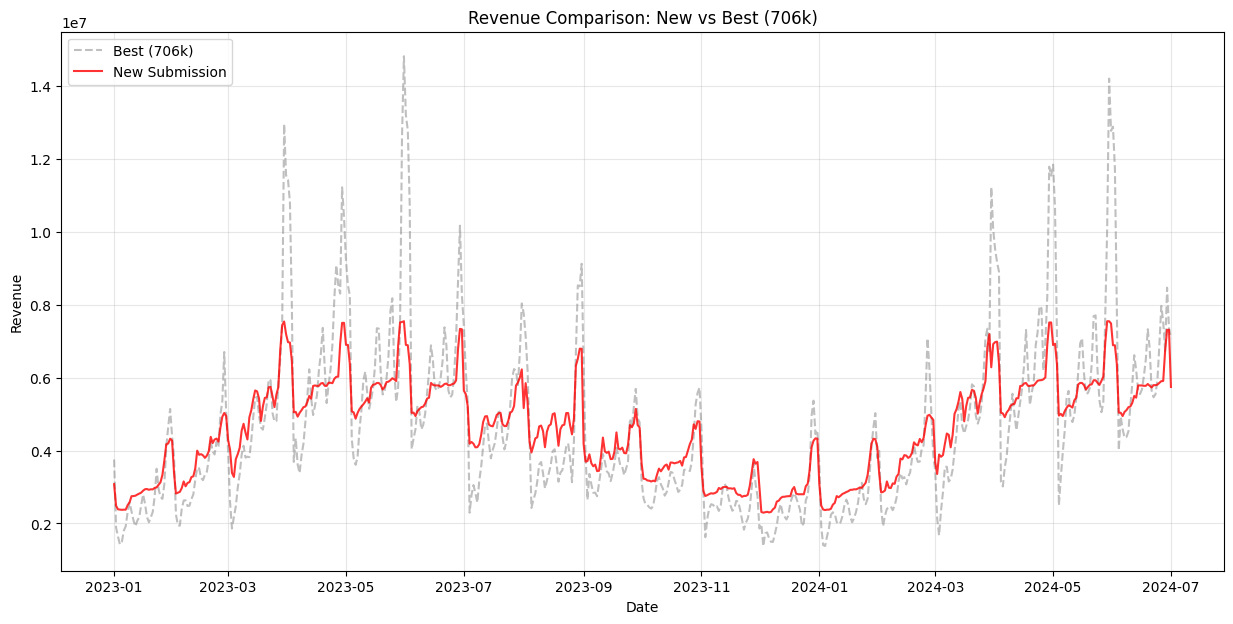

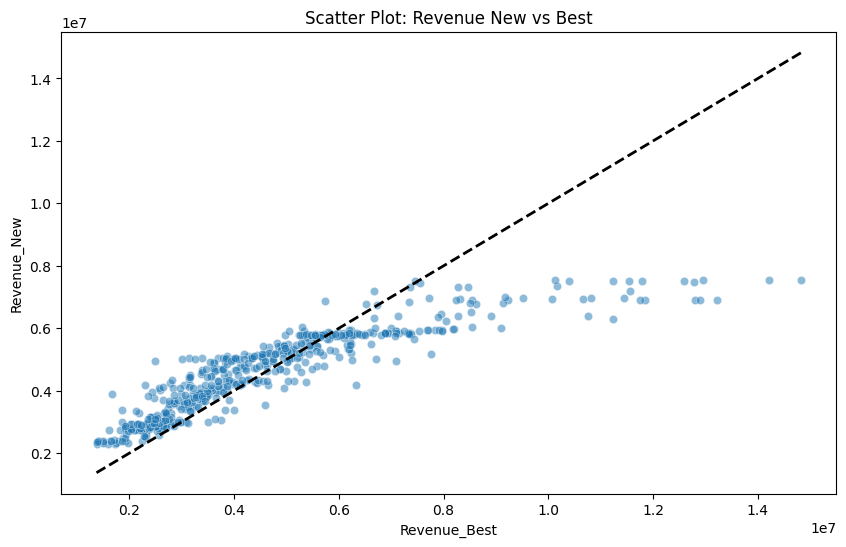

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the files
sub_new = pd.read_csv('submission_xgb.csv')
sub_best = pd.read_csv('submission_best_706k.csv')

# Ensure Date is datetime
sub_new['Date'] = pd.to_datetime(sub_new['Date'])
sub_best['Date'] = pd.to_datetime(sub_best['Date'])

# Merge to compare
df_comp = pd.merge(sub_new, sub_best, on='Date', suffixes=('_New', '_Best'))

# Basic Stats
stats_rev = df_comp[['Revenue_New', 'Revenue_Best']].describe()
stats_cogs = df_comp[['COGS_New', 'COGS_Best']].describe()

# Metrics
corr_rev = df_comp['Revenue_New'].corr(df_comp['Revenue_Best'])
mae_rev = np.mean(np.abs(df_comp['Revenue_New'] - df_comp['Revenue_Best']))
rmse_rev = np.sqrt(np.mean((df_comp['Revenue_New'] - df_comp['Revenue_Best'])**2))

corr_cogs = df_comp['COGS_New'].corr(df_comp['COGS_Best'])
mae_cogs = np.mean(np.abs(df_comp['COGS_New'] - df_comp['COGS_Best']))

# Differences
df_comp['Diff_Rev'] = df_comp['Revenue_New'] - df_comp['Revenue_Best']
df_comp['Abs_Diff_Rev'] = df_comp['Diff_Rev'].abs()
top_diffs = df_comp.sort_values('Abs_Diff_Rev', ascending=False).head(10)

# Print results
print("--- Descriptive Stats: Revenue ---")
print(stats_rev)
print("\n--- Descriptive Stats: COGS ---")
print(stats_cogs)
print(f"\nRevenue Correlation: {corr_rev:.4f}")
print(f"Revenue MAE: {mae_rev:,.2f}")
print(f"Revenue RMSE: {rmse_rev:,.2f}")
print(f"COGS Correlation: {corr_cogs:.4f}")

print("\n--- Top 10 Days with Highest Revenue Difference ---")
print(top_diffs[['Date', 'Revenue_New', 'Revenue_Best', 'Diff_Rev']])

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(df_comp['Date'], df_comp['Revenue_Best'], label='Best (706k)', color='gray', alpha=0.5, linestyle='--')
plt.plot(df_comp['Date'], df_comp['Revenue_New'], label='New Submission', color='red', alpha=0.8)
plt.title('Revenue Comparison: New vs Best (706k)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('revenue_comparison.png')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_comp, x='Revenue_Best', y='Revenue_New', alpha=0.5)
plt.plot([df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         [df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         'k--', lw=2)
plt.title('Scatter Plot: Revenue New vs Best')
plt.savefig('revenue_scatter.png')

In [ ]:
import pandas as pd
import numpy as np

# 1. Lấy dự báo từ LightGBM 
# (Nhớ xả nén bằng np.expm1 vì target lúc train đã bọc np.log1p)
multiplier_lgbm = 1.25
preds_lgbm_rev = np.maximum(0, np.expm1(model_revenue.predict(X_test)))
preds_lgbm_cogs = np.maximum(0, np.expm1(model_cogs.predict(X_test)))
preds_lgbm_rev1 = multiplier_lgbm * preds_lgbm_rev
preds_lgbm_cogs1 = multiplier_lgbm * preds_lgbm_cogs

# (Giả sử bạn đã chạy đoạn code XGBoost ở trên và có sẵn 2 biến này)
# preds_xgb_rev = np.maximum(0, np.expm1(model_xgb_rev.predict(X_test)))
# preds_xgb_cogs = np.maximum(0, np.expm1(model_xgb_cogs.predict(X_test)))
z1 = 0.5
z2 = 0.5
final_preds_rev = (z1 * preds_lgbm_rev1) + (z2 * preds_xgb_rev)
final_preds_cogs = (z1 * preds_lgbm_cogs1) + (z2 * preds_xgb_cogs)

# 3. Đọc file mẫu từ BTC
sample_sub = pd.read_csv('sample_submission.csv')
sample_sub['Date'] = pd.to_datetime(sample_sub['Date'])

# Bơm kết quả Ensemble vào
sample_sub['Revenue'] = final_preds_rev
sample_sub['COGS'] = final_preds_cogs

# 4. Lọc đúng 3 cột và xuất file
submission_ensemble = sample_sub[['Date', 'Revenue', 'COGS']]
submission_ensemble.to_csv('submission_ensemble_new.csv', index=False,float_format='%.0f')

print("Đã xuất file submission_ensemble_new.csv")

Đã xuất file submission_ensemble_new.csv


--- Descriptive Stats: Revenue ---
        Revenue_New  Revenue_Best
count  5.480000e+02  5.480000e+02
mean   4.282264e+06  4.616867e+06
std    1.622155e+06  2.333540e+06
min    1.599592e+06  1.373891e+06
25%    2.949475e+06  2.831448e+06
50%    4.217780e+06  4.098495e+06
75%    5.308291e+06  5.721849e+06
max    1.029220e+07  1.482447e+07

--- Descriptive Stats: COGS ---
           COGS_New     COGS_Best
count  5.480000e+02  5.480000e+02
mean   3.702817e+06  3.929090e+06
std    1.489605e+06  1.996735e+06
min    1.279060e+06  1.074318e+06
25%    2.485333e+06  2.437954e+06
50%    3.570844e+06  3.558643e+06
75%    4.587051e+06  4.706785e+06
max    9.582756e+06  1.213713e+07

Revenue Correlation: 0.9466
Revenue MAE: 594,634.40
Revenue RMSE: 1,010,345.23
COGS Correlation: 0.9538

--- Top 10 Days with Highest Revenue Difference ---
          Date  Revenue_New  Revenue_Best      Diff_Rev
150 2023-05-31      9509629  1.482447e+07 -5.314846e+06
152 2023-06-02      7648229  1.279547e+07 -5.14724

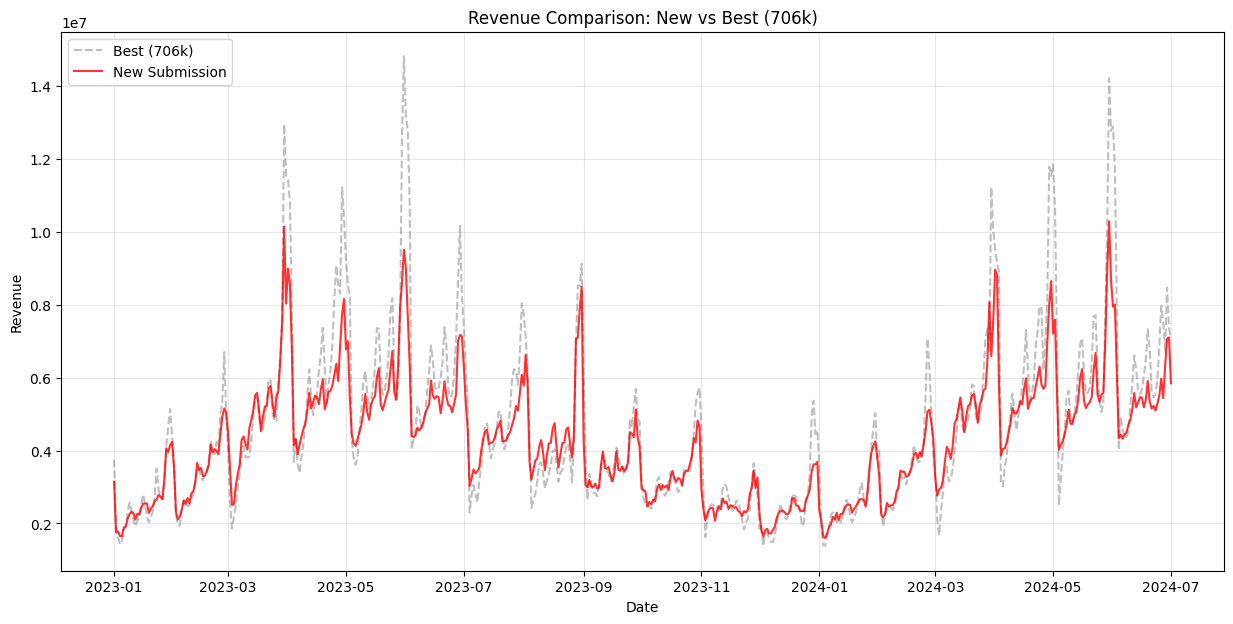

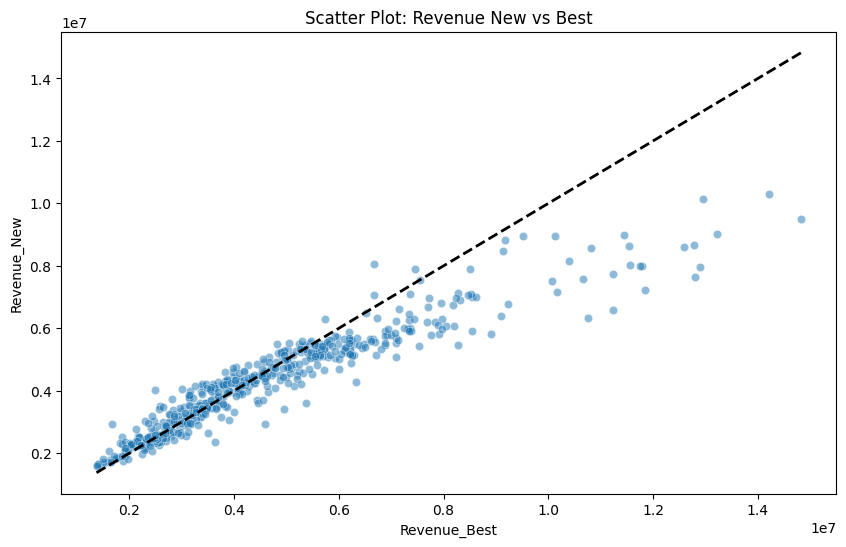

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the files
sub_new = pd.read_csv('submission_ensemble_new.csv')
sub_best = pd.read_csv('submission_best_706k.csv')

# Ensure Date is datetime
sub_new['Date'] = pd.to_datetime(sub_new['Date'])
sub_best['Date'] = pd.to_datetime(sub_best['Date'])

# Merge to compare
df_comp = pd.merge(sub_new, sub_best, on='Date', suffixes=('_New', '_Best'))

# Basic Stats
stats_rev = df_comp[['Revenue_New', 'Revenue_Best']].describe()
stats_cogs = df_comp[['COGS_New', 'COGS_Best']].describe()

# Metrics
corr_rev = df_comp['Revenue_New'].corr(df_comp['Revenue_Best'])
mae_rev = np.mean(np.abs(df_comp['Revenue_New'] - df_comp['Revenue_Best']))
rmse_rev = np.sqrt(np.mean((df_comp['Revenue_New'] - df_comp['Revenue_Best'])**2))

corr_cogs = df_comp['COGS_New'].corr(df_comp['COGS_Best'])
mae_cogs = np.mean(np.abs(df_comp['COGS_New'] - df_comp['COGS_Best']))

# Differences
df_comp['Diff_Rev'] = df_comp['Revenue_New'] - df_comp['Revenue_Best']
df_comp['Abs_Diff_Rev'] = df_comp['Diff_Rev'].abs()
top_diffs = df_comp.sort_values('Abs_Diff_Rev', ascending=False).head(10)

# Print results
print("--- Descriptive Stats: Revenue ---")
print(stats_rev)
print("\n--- Descriptive Stats: COGS ---")
print(stats_cogs)
print(f"\nRevenue Correlation: {corr_rev:.4f}")
print(f"Revenue MAE: {mae_rev:,.2f}")
print(f"Revenue RMSE: {rmse_rev:,.2f}")
print(f"COGS Correlation: {corr_cogs:.4f}")

print("\n--- Top 10 Days with Highest Revenue Difference ---")
print(top_diffs[['Date', 'Revenue_New', 'Revenue_Best', 'Diff_Rev']])

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(df_comp['Date'], df_comp['Revenue_Best'], label='Best (706k)', color='gray', alpha=0.5, linestyle='--')
plt.plot(df_comp['Date'], df_comp['Revenue_New'], label='New Submission', color='red', alpha=0.8)
plt.title('Revenue Comparison: New vs Best (706k)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('revenue_comparison.png')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_comp, x='Revenue_Best', y='Revenue_New', alpha=0.5)
plt.plot([df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         [df_comp['Revenue_Best'].min(), df_comp['Revenue_Best'].max()], 
         'k--', lw=2)
plt.title('Scatter Plot: Revenue New vs Best')
plt.savefig('revenue_scatter.png')

--- SO SÁNH DOANH THU: DỰ ĐOÁN (2023-2024) VS THỰC TẾ (2021-2022) ---
Tổng doanh thu thực tế (2020 - 2021): 1,691,669,924 VNĐ
Tổng doanh thu dự đoán (2023 - 2024): 2,500,102,040 VNĐ
Tốc độ tăng trưởng kỳ vọng (Growth Rate): 47.79%


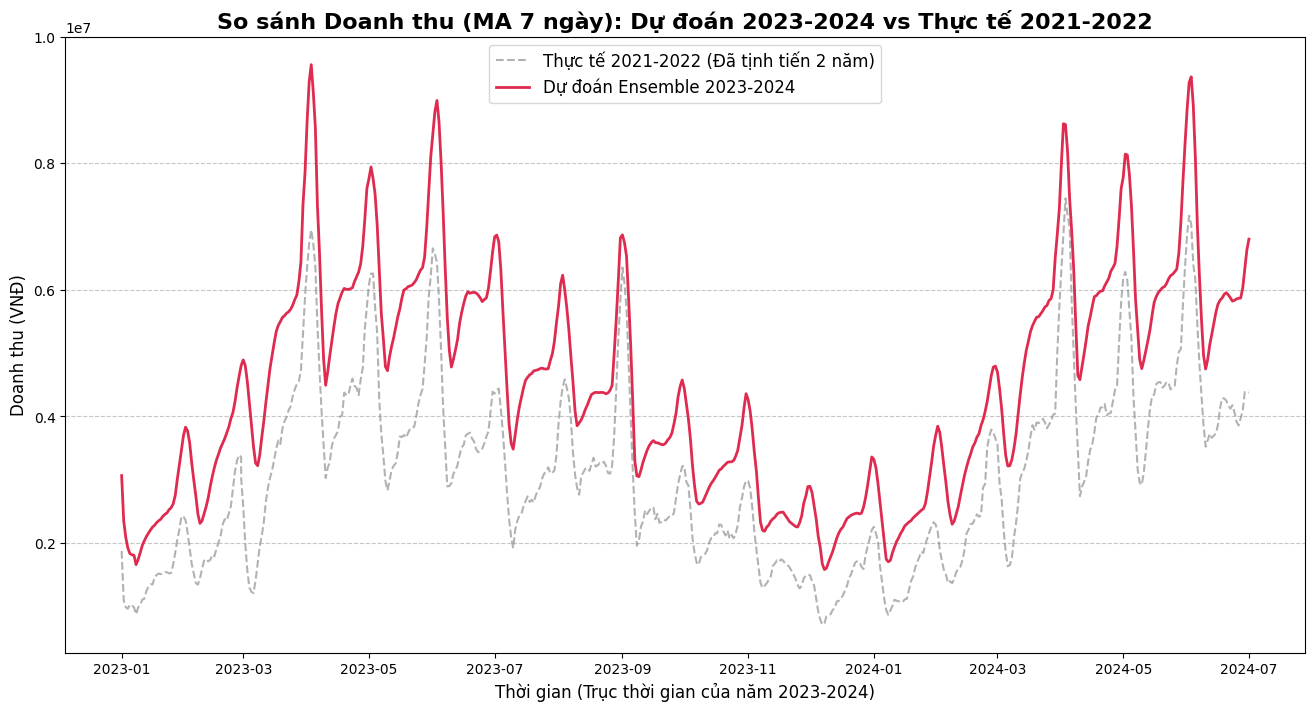

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- SO SÁNH DOANH THU: DỰ ĐOÁN (2023-2024) VS THỰC TẾ (2021-2022) ---")

# 1. Đọc dữ liệu
# Dữ liệu dự đoán của bạn
sub_new = pd.read_csv('submission_ensemble_new.csv') # Đổi lại tên file nếu cần
sub_new['Date'] = pd.to_datetime(sub_new['Date'])

# Dữ liệu lịch sử thực tế (sales.csv)
sales = pd.read_csv('sales.csv')
sales['Date'] = pd.to_datetime(sales['Date'])

# 2. Lọc mốc thời gian tương ứng
# Tập dự đoán kéo dài từ 01/01/2023 đến 01/07/2024
pred_df = sub_new[(sub_new['Date'] >= '2023-01-01') & (sub_new['Date'] <= '2024-07-01')].copy()

# Tập lịch sử tương ứng: Lùi lại đúng 2 năm (01/01/2021 đến 01/07/2022)
hist_df = sales[(sales['Date'] >= '2020-01-01') & (sales['Date'] <= '2021-07-01')].copy()

# 3. Tịnh tiến thời gian (Shift Date) để vẽ chung 1 trục X
# Cộng thêm 2 năm (chính xác là 730 ngày) vào dữ liệu lịch sử
hist_df['Shifted_Date'] = hist_df['Date'] + pd.DateOffset(years=3)

# 4. Làm mượt đồ thị (Smoothing) để dễ nhìn
# Doanh thu theo ngày rất nhiễu, ta dùng Trung bình trượt 7 ngày (Rolling 7-day)
pred_df['Revenue_Smooth'] = pred_df['Revenue'].rolling(window=7, min_periods=1).mean()
hist_df['Revenue_Smooth'] = hist_df['Revenue'].rolling(window=7, min_periods=1).mean()

# 5. In thống kê tổng quan (Sanity Check)
total_hist = hist_df['Revenue'].sum()
total_pred = pred_df['Revenue'].sum()
growth_rate = ((total_pred - total_hist) / total_hist) * 100

print(f"Tổng doanh thu thực tế (2020 - 2021): {total_hist:,.0f} VNĐ")
print(f"Tổng doanh thu dự đoán (2023 - 2024): {total_pred:,.0f} VNĐ")
print(f"Tốc độ tăng trưởng kỳ vọng (Growth Rate): {growth_rate:.2f}%")

# 6. Vẽ biểu đồ so sánh
plt.figure(figsize=(16, 8))

# Vẽ đường lịch sử (Màu xám, nét đứt để làm nền)
plt.plot(hist_df['Shifted_Date'], hist_df['Revenue_Smooth'], 
         label='Thực tế 2021-2022 (Đã tịnh tiến 2 năm)', 
         color='gray', alpha=0.6, linestyle='--', linewidth=1.5)

# Vẽ đường dự đoán (Màu xanh/đỏ nổi bật)
plt.plot(pred_df['Date'], pred_df['Revenue_Smooth'], 
         label='Dự đoán Ensemble 2023-2024', 
         color='crimson', alpha=0.9, linewidth=2)

# Cài đặt biểu đồ
plt.title('So sánh Doanh thu (MA 7 ngày): Dự đoán 2023-2024 vs Thực tế 2021-2022', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian (Trục thời gian của năm 2023-2024)', fontsize=12)
plt.ylabel('Doanh thu (VNĐ)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Lưu đồ